In [2]:
%load_ext autoreload 
%autoreload 2
import cv2
import json, os, cv2
from pathlib import Path
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import xarray as xr
import seaborn as sns
import h5py as hf
from tqdm import tqdm
from tqdm import tqdm
import itertools 
from scipy.interpolate import interp1d
from scipy import signal
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
import os, fnmatch
from scipy.spatial.distance import cdist

import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')
#sys.path.append(r'C:\Users\nlab\Documents\GitHub\obstacle_avoidance\plots') # go to parent dir 

from utils.base_functions import *
from src.utils.auxiliary import flatten_series
from src.utils.path import find
from src.base import BaseInput
from plots.plots import plot_oa
from plots.plots2 import *
#from plots.plots import *
import warnings
warnings.filterwarnings('ignore')

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
c:\Users\nlab\anaconda3\envs\ephys0\lib\site-packages\deeplabcut\__init__.py:78: UserWarning: 
        As PyTorch is not installed, unsupervised identity learning will not be available.
        Please run `pip install torch`, or ignore this warning.
        
  warnings.warn(


In [1]:
session = plot_oa(r"D:\obstacle_avoidance\metadata\compiled_data\G8CK1_G8CK_oa_09_08_07.json",'blank')
session.gather_session_df('obstacle',6)

NameError: name 'plot_oa' is not defined

In [4]:
session = plot_oa(r"D:\obstacle_avoidance\metadata\compiled_data\G8CK1_G8CK_oa_09_08_07.json",'blank')
session.gather_session_df('obstacle',6)
df = session.df

In [5]:
calculate_relative_distance_goal(df)

calculate_relative_distance(df)

angle_to_open_corner(df)

angle_to_target_port(df)

zero_out_angle(df)

zero_out_angle_target_port(df)

df_tortuosity(df)

lateral_error_open_corner(df)

find_consective_trials(df)


In [6]:
condition_dict = {'blackblack': ['black','black'], 'whiteblack': ['white','black'],'whitenoise':['white','noise'],
                  'blackwhite':['black','white'], 'noisewhite':['noise','white'], 'noisenoise':['noise','noise'],
                  'blacknoise':['black','noise'], 'whitewhite':['white','white'],'whtewhite':['white','white'],'noiseblack':['noise','black']}

for ind, row in df.iterrows():
    for key in condition_dict.keys():
        if key == row.condition:
            df.at[ind,'wall'] = condition_dict.get(key)[0]
            df.at[ind,'obstacle'] = condition_dict.get(key)[1]

In [28]:
get_mean_median_trace_by_condition(df,'wall')

In [8]:
df.condition

0        blackblack
1        blackblack
2        blackblack
3        blackblack
4        blackblack
            ...    
31623    blacknoise
31624    blacknoise
31625    blacknoise
31626    blacknoise
31627    blacknoise
Name: condition, Length: 28682, dtype: object

In [ ]:
for direction, direction_frame in self.df.groupby(['odd']):
    for cluster, cluster_frame in direction_frame.groupby(['obstacle_cluster']):
        for start, start_frame in cluster_frame.groupby(['start']):
                        array = np.zeros([len(start_frame), 50])
                        count = 0
                        for ind,row in start_frame.iterrows():
                            array[count,:] = row['interp_ts_nose_y_cm']
                            count += 1
                        mean_trace = np.nanmean(array,axis=0)
                        median_trace = np.nanmedian(array,axis = 0)
                        std_trace = np.nanstd(array,axis=0)
                        mad_trace = stats.median_abs_deviation(array,axis = 0,nan_policy='omit')

                        x = self.df.loc[(self.df['obstacle_cluster'] ==cluster) & (self.df['start']==start)&(self.df['odd'] ==direction)]
                        for ind,row in x.iterrows():
                            self.df.at[ind,'mean_interp_ts_nose_y_cm']= mean_trace.astype(object)

                            self.df.at[ind,'median_interp_ts_nose_y_cm']= median_trace.astype(object)

                            self.df.at[ind,'std_interp_ts_nose_y_cm']= std_trace.astype(object)

                            self.df.at[ind,'mad_interp_ts_nose_y_cm']= mad_trace.astype(object)

In [ ]:
get_mean_median_trace_by_condition
condition_by_start_obstalce_average

In [ ]:
df.wall_mean_interp_ts_nose_y_cm.loc[(df['obstacle_cluster']==0)&(df['wall']=='white')]

In [ ]:
df.wall_mean_interp_ts_nose_y_cm.loc[(df['obstacle_cluster']==0)&(df['wall']=='black')]

In [ ]:
pd.unique(df.wall_mean_interp_ts_nose_y_cm)

In [11]:
def get_mean_median_trace_by_condition(df,condition):
    for direction, direction_frame in df.groupby(['odd']):
        for cluster, cluster_frame in direction_frame.groupby(['obstacle_cluster']):
            for start, start_frame in cluster_frame.groupby(['start']):
                for variable, variable_frame in start_frame.groupby([condition]):
                    array = np.zeros([len(variable_frame), 50])
                    count = 0
                    for ind,row in variable_frame.iterrows():
                        array[count,:] = row['interp_ts_nose_y_cm']
                        count += 1
                    mean_trace = np.nanmean(array,axis=0)
                    median_trace = np.nanmedian(array,axis = 0)
                    std_trace = np.nanstd(array,axis=0)
                    mad_trace = stats.median_abs_deviation(array,axis = 0,nan_policy='omit')
                    x = df.loc[(df['obstacle_cluster'] ==cluster) & (df['start']==start)&(df['odd'] ==direction)&(df[condition]==variable)]
                    for ind,row in x.iterrows():
                           df.at[ind,condition + '_mean_interp_ts_nose_y_cm']= mean_trace.astype(object)

                           df.at[ind,condition + '_median_interp_ts_nose_y_cm']= median_trace.astype(object)

                           df.at[ind,condition + '_std_interp_ts_nose_y_cm']= std_trace.astype(object)

                           df.at[ind,condition + '_mad_interp_ts_nose_y_cm']= mad_trace.astype(object)

                    


In [ ]:
def condition_by_start_obstalce_average(df,condition):
        #savepath = "D:/obstacle_avoidance/recordings"
        #savepath_session = os.path.join(*[savepath,'figures'])
        ##savepath_session = os.path.join(*[savepath,str(pd.unique(df.date).item()),str(pd.unique(df.animal).item()),str(pd.unique(df.task).item())])
        #pdf = PdfPages(os.path.join((savepath_session), str(date)+ 'by_' +'_start_'+'obstacle' + 'consecutive.pdf'))
        key='start'
        fig = plt.figure(constrained_layout=False, figsize=(20, 10),dpi=90)
        fig.suptitle('by ' + df[condition].unique() + ' '+ 'and ' +'obstacle ')
        spec2 = gridspec.GridSpec(ncols=2, nrows=1, figure=fig)


        """Right"""
        panel_1 = gridspec.GridSpecFromSubplotSpec(3,2,subplot_spec=spec2[0])
        ax1 = fig.add_subplot(panel_1[0,0])
        plot_arena(df,ax1)
        ax2 = fig.add_subplot(panel_1[0,1])
        plot_arena(df,ax2)
        ax2.set_title('right')
        ax3 = fig.add_subplot(panel_1[1,0])
        plot_arena(df,ax3)
        ax4 = fig.add_subplot(panel_1[1,1])
        plot_arena(df,ax4)
        ax5 = fig.add_subplot(panel_1[2,0])
        plot_arena(df,ax5)
        ax6 = fig.add_subplot(panel_1[2,1])
        plot_arena(df,ax6)

        right_axs = [ax1,ax2,ax3,ax4,ax5,ax6]


        """Left """
        panel_2 = gridspec.GridSpecFromSubplotSpec(3,2,subplot_spec=spec2[1])
        ax7 = fig.add_subplot(panel_2[0,0])
        plot_arena(df,ax7)
        ax8 = fig.add_subplot(panel_2[0,1])
        plot_arena(df,ax8)
        ax8.set_title('left')
        ax9 = fig.add_subplot(panel_2[1,0])
        plot_arena(df,ax9)
        ax10 = fig.add_subplot(panel_2[1,1])
        plot_arena(df,ax10)
        ax11= fig.add_subplot(panel_2[2,0])
        plot_arena(df,ax11)
        ax12 = fig.add_subplot(panel_2[2,1])
        plot_arena(df,ax12)

        left_axs = [ax7,ax8,ax9,ax10,ax11,ax12]




        """ plot trials"""
        right_obstacle_dict = dict(zip(pd.unique(df['obstacle_cluster'].sort_values().to_list()),right_axs))
        left_obstacle_dict = dict(zip(pd.unique(df['obstacle_cluster'].sort_values().to_list()),left_axs))

        for direction, direction_frame in df.groupby(['odd']):
            for cluster, cluster_frame in direction_frame.groupby(['obstacle_cluster']):
                #cluster_frame = cluster_frame.sample(num_sample)
                right_obstacle_axis = right_obstacle_dict.get(cluster)
                left_obstacle_axis = left_obstacle_dict.get(cluster)
                plot_obstacle(cluster_frame,right_obstacle_axis,cluster)
                plot_obstacle(cluster_frame,left_obstacle_axis,cluster)
                right_obstacle_axis.set_title(str(cluster))
                left_obstacle_axis.set_title(str(cluster))

                for start, start_frame in cluster_frame.groupby(['start']):

                    if direction == 'right':
                        if start == 'top':
                            if cluster in [2,3]:
                                right_obstacle_axis.plot(np.linspace(10,50,50),start_frame[condition + '_median_interp_ts_nose_y_cm'].to_numpy()[0],c = 'black')
                                right_obstacle_axis.fill_between(np.linspace(10,50,50), start_frame[condition + '_median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame[condition+'_mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame[condition+'_median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame[condition+'_mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='black', alpha=0.5)

                            else:
                                right_obstacle_axis.plot(np.linspace(10,50,50),start_frame[condition + '_mean_interp_ts_nose_y_cm'].to_numpy()[0],c = 'black')
                                right_obstacle_axis.fill_between(np.linspace(10,50,50), start_frame[condition + '_mean_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame['std_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame[condition+'_mean_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame['std_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='black', alpha=0.5)
                        if start == 'bottom':
                            if cluster in [2,3]:
                                right_obstacle_axis.plot(np.linspace(10,50,50),start_frame[condition + '_median_interp_ts_nose_y_cm'].to_numpy()[0],c = 'red')
                                right_obstacle_axis.fill_between(np.linspace(10,50,50), start_frame[condition + '_median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame[condition+'_mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame[condition+'_median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame[condition+'_mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='red', alpha=0.5)
                            else:
                                right_obstacle_axis.plot(np.linspace(10,50,50),start_frame[condition + '_mean_interp_ts_nose_y_cm'].to_numpy()[0],c = 'red')
                                right_obstacle_axis.fill_between(np.linspace(10,50,50), start_frame[condition + '_mean_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame['std_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame[condition+'_mean_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame['std_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='red', alpha=0.5)


                    if direction == 'left':
                        if start == 'top':
                             if cluster in [2,3]:
                                left_obstacle_axis.plot(np.linspace(10,50,50),start_frame[condition + '_median_interp_ts_nose_y_cm'].to_numpy()[0],c = 'black')
                                left_obstacle_axis.fill_between(np.linspace(10,50,50), start_frame[condition + '_median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame[condition+'_mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame[condition+'_median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame[condition+'_mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='black', alpha=0.5)
                             else:
                                left_obstacle_axis.plot(np.linspace(10,50,50),start_frame[condition + '_mean_interp_ts_nose_y_cm'].to_numpy()[0],c = 'black')
                                left_obstacle_axis.fill_between(np.linspace(10,50,50), start_frame[condition + '_mean_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame['std_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame[condition+'_mean_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame['std_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='black', alpha=0.5)
                        if start == 'bottom':
                            if cluster in [2,3]:
                                left_obstacle_axis.plot(np.linspace(10,50,50),start_frame[condition + '_median_interp_ts_nose_y_cm'].to_numpy()[0],c = 'red')
                                left_obstacle_axis.fill_between(np.linspace(10,50,50), start_frame[condition + '_median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame[condition+'_mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame[condition+'_median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame[condition+'_mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='red', alpha=0.5)

                            else:
                                left_obstacle_axis.plot(np.linspace(10,50,50),start_frame[condition + '_mean_interp_ts_nose_y_cm'].to_numpy()[0],c = 'red')
                                left_obstacle_axis.fill_between(np.linspace(10,50,50), start_frame[condition + '_mean_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame['std_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame[condition+'_mean_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame['std_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='red', alpha=0.5)

        
    

In [13]:
df.angle_to_corner

0        [nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
1        [34.75772067812996, 34.471556909211415, 34.888...
2        [29.927031799860195, 26.9148038714865, 20.2980...
3        [46.18320849515615, 47.48269831686545, 47.5739...
4        [37.58304637186391, 33.80927852148717, 32.0768...
                               ...                        
31623    [44.090749822239594, 44.87563788490937, 45.968...
31624    [84.24065942034393, 83.77071238932787, 82.7221...
31625    [44.588922005052694, 44.572780189260804, 44.78...
31626    [75.55351817817737, 76.74240317901055, 78.0907...
31627    [21.36425523755419, 25.401608831462276, 30.216...
Name: angle_to_corner, Length: 28682, dtype: object

In [19]:
test.angle_to_corner.to_numpy()[0]

array([74.14857255838011, 72.949415702417, 73.13642239881159,
       74.54672922868984, 75.97247134197433, 77.62799677893466,
       80.99964095059381, 86.84723149685007, 90.8075544183992,
       95.49209593779955, 100.79273741033757, 106.50939061969422,
       113.08162602259067, 119.84451505046684, 126.58695444128024,
       132.3225216752356, 138.09375852050252, 143.6854985620461,
       148.83117700388522, 153.1507612165712, 156.6707671106738,
       159.71865092529018, 162.9388411542388, 165.49783450417857,
       167.42989765975813, 169.00978608954983, 170.365712232352,
       171.5578229798968, 172.72381249107048, 173.78670398861712,
       174.7396509281149, 175.41779769919552, 175.97431112922666,
       176.6474929875751, 177.16970574832197, 177.57658914965745,
       178.01530421640575, 178.43418156602036, 178.87447565408272,
       178.97801465931133, 179.23063230883795, 179.55943636647982,
       179.76692162696807, 179.88070285982954, 179.89367352958644,
       179.8326791

In [26]:
test = df.sample(1)
print(test.obstacle_cluster,test.odd,test.start)

20824    0
Name: obstacle_cluster, dtype: int32 20824    right
Name: odd, dtype: object 20824    top
Name: start, dtype: object


In [35]:
test.gt_obstacleBR_x_cm.item()

25.182481722467536

In [30]:
len(test.gt_obstacleBR_x_cm.to_numpy()[0])

TypeError: object of type 'numpy.float64' has no len()

In [36]:
np.zeros(10)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [38]:
nose_x = test.ts_nose_x_cm.to_numpy()[0]
nose_y = test.ts_nose_y_cm.to_numpy()[0]
obstacle_x = test.gt_obstacleBR_x_cm.item()
obstalce_y = test.gt_obstacleBR_y_cm.item()
angs = []
for i in list(range(len(nose_x))):
    x = obstacle_x - nose_x[i]
    y = obstalce_y - nose_y[i]
    ang = np.arctan(x/y)
    angs.append(ang)



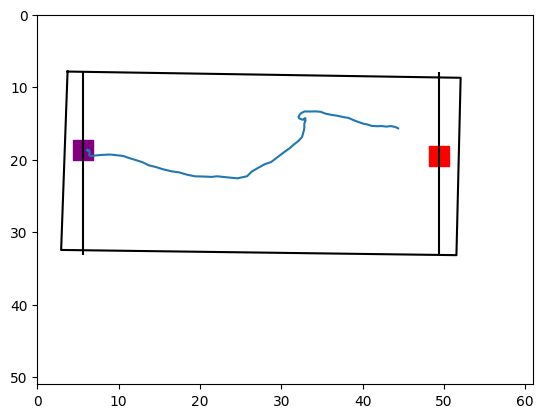

In [43]:
fig,ax = plt.subplots()
ax.plot(nose_x,nose_y)
plot_arena(test,ax)

In [ ]:
nose_x_cm

In [ ]:
df.condition.unique()

In [ ]:
condition_dict = {'blackblack': ['black','black'], 'whiteblack': ['white','black'],'whitenoise':['white','noise'],
                  'blackwhite':['black','white'], 'noisewhite':['noise','white'], 'noisenoise':['noise','noise'],
                  'blacknoise':['black','noise'], 'whitewhite':['white','white'],'whtewhite':['white','white'],'noiseblack':['noise','black']}

for ind, row in df.iterrows():
    for key in condition_dict.keys():
        if key == row.condition:
            df.at[ind,'wall'] = condition_dict.get(key)[0]
            df.at[ind,'obstacle'] = condition_dict.get(key)[1]
            

In [ ]:
condition_dict.get(key)[0] + condition_dict.get(key)[1]

In [ ]:
condition_dict = {'blackblack': ['black','black'], 'whiteblack': ['white','black'],'whitenoise':['white','noise'],
                  'blackwhite':['black','white'], 'noisewhite':['noise','white'], 'noisenoise':['noise','noise'],
                  'blacknoise':['black','noise'], 'whitewhite':['white','white'],'whtewhite':['white','white'],'noiseblack':['noise','black']}

for ind, row in long.iterrows():
    for key in condition_dict.keys():
        if key == row.condition:
            long.at[ind,'wall'] = condition_dict.get(key)[0]
            long.at[ind,'obstalce'] = condition_dict.get(key)[1]
            long.at[ind,'condition'] = condition_dict.get(key)[0] + condition_dict.get(key)[1]
            

            

In [12]:
get_mean_median_trace_by_condition(df,'wall')
get_mean_median_trace_by_condition(df,'obstacle')
get_mean_median_trace_by_condition(df,'condition')


In [14]:
long,short,middle = create_df_by_type(df)

In [18]:
long

,level_0,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,...,wall_std_interp_ts_nose_y_cm,wall_mad_interp_ts_nose_y_cm,obstacle_mean_interp_ts_nose_y_cm,obstacle_median_interp_ts_nose_y_cm,obstacle_std_interp_ts_nose_y_cm,obstacle_mad_interp_ts_nose_y_cm,condition_mean_interp_ts_nose_y_cm,condition_median_interp_ts_nose_y_cm,condition_std_interp_ts_nose_y_cm,condition_mad_interp_ts_nose_y_cm
1,1,1,45287.166080,45289.095539,"[45287.173977, 45287.191155, 45287.207692, 452...","[[180, 181, 182, 183, 184, 185, 186, 187, 188,...","[659.1345825195312, 659.9591064453125, 658.926...","[262.79779052734375, 262.86639404296875, 262.2...","[640.8193359375, 642.065185546875, 641.9094848...","[259.280517578125, 258.0514221191406, 258.0626...",...,"[0.9340920238355253, 1.0090738898790987, 1.065...","[0.6101730196452948, 0.6653870442929701, 0.708...","[19.85635146674682, 20.09457132199585, 20.3637...","[19.811777981827674, 20.036769641893763, 20.30...","[0.920678373069903, 0.9882330318872281, 1.0493...","[0.5250046473838221, 0.5266987559991669, 0.556...","[20.2166185024379, 20.437180579660254, 20.7117...","[20.151438834520032, 20.38486919264974, 20.610...","[0.7100621638541298, 0.7778932320928774, 0.836...","[0.47821114215474125, 0.513118354761886, 0.519..."
13,16,19,45329.628812,45331.279616,"[45329.63872, 45329.655552, 45329.672179, 4532...","[[2727, 2728, 2729, 2730, 2731, 2732, 2733, 27...","[662.4247436523438, 662.3223876953125, 662.512...","[268.860595703125, 267.6027526855469, 266.1972...","[647.87255859375, 648.4732055664062, 648.97534...","[259.42236328125, 258.2563171386719, 256.81088...",...,"[0.9340920238355253, 1.0090738898790987, 1.065...","[0.6101730196452948, 0.6653870442929701, 0.708...","[19.85635146674682, 20.09457132199585, 20.3637...","[19.811777981827674, 20.036769641893763, 20.30...","[0.920678373069903, 0.9882330318872281, 1.0493...","[0.5250046473838221, 0.5266987559991669, 0.556...","[20.2166185024379, 20.437180579660254, 20.7117...","[20.151438834520032, 20.38486919264974, 20.610...","[0.7100621638541298, 0.7778932320928774, 0.836...","[0.47821114215474125, 0.513118354761886, 0.519..."
30,36,39,45373.836518,45375.630643,"[45373.837363, 45373.8539, 45373.870758, 45373...","[[5378, 5379, 5380, 5381, 5382, 5383, 5384, 53...","[658.9888916015625, 659.8367919921875, 660.936...","[262.6311340332031, 262.8354187011719, 262.632...","[643.4417114257812, 645.067626953125, 646.9371...","[251.00555419921875, 250.87335205078125, 250.5...",...,"[0.9340920238355253, 1.0090738898790987, 1.065...","[0.6101730196452948, 0.6653870442929701, 0.708...","[19.85635146674682, 20.09457132199585, 20.3637...","[19.811777981827674, 20.036769641893763, 20.30...","[0.920678373069903, 0.9882330318872281, 1.0493...","[0.5250046473838221, 0.5266987559991669, 0.556...","[20.2166185024379, 20.437180579660254, 20.7117...","[20.151438834520032, 20.38486919264974, 20.610...","[0.7100621638541298, 0.7778932320928774, 0.836...","[0.47821114215474125, 0.513118354761886, 0.519..."
32,38,41,45378.760268,45380.583091,"[45378.772224, 45378.789875, 45378.805862, 453...","[[5674, 5675, 5676, 5677, 5678, 5679, 5680, 56...","[660.15234375, 661.2433471679688, 661.91552734...","[263.1383361816406, 264.3952941894531, 263.993...","[645.3707885742188, 647.1256103515625, 649.435...","[252.9916229248047, 253.55458068847656, 254.19...",...,"[0.9340920238355253, 1.0090738898790987, 1.065...","[0.6101730196452948, 0.6653870442929701, 0.708...","[19.85635146674682, 20.09457132199585, 20.3637...","[19.811777981827674, 20.036769641893763, 20.30...","[0.920678373069903, 0.9882330318872281, 1.0493...","[0.5250046473838221, 0.5266987559991669, 0.556...","[20.2166185024379, 20.437180579660254, 20.7117...","[20.151438834520032, 20.38486919264974, 20.610...","[0.7100621638541298, 0.7778932320928774, 0.836...","[0.47821114215474125, 0.513118354761886, 0.519..."
51,60,63,45427.887513,45429.657356,"[45427.889011, 45427.905907, 45427.92335

In [20]:
row[1]['distance_from_edge'][:length]

array([10.910866277641496, 11.519354991608154, 11.930096763055353,
       12.305501304183409, 13.035610225497358, 13.72522490775571,
       14.484932534807065, 15.145746405162228, 15.801110254920907,
       16.379691473728442, 17.06452330085621, 17.538025958783614,
       18.107239813819852, 18.568679398863722, 19.00404092836527,
       19.46358269813112, 19.860690402337568, 20.14079621689821,
       20.4292370919079, 20.68889969438826, 20.97598369909229,
       21.382562448189738, 21.845597820902057, 22.13975468111964,
       22.39744734232567, 22.62572612065985, 22.879848545048326,
       23.03015912136695, 23.149148983786162, 23.268129830455834,
       23.323513579875538, 23.37476811600626, 23.458871535583285,
       23.509995343345686, 23.593224235217406, 23.684517715051996,
       23.769712040323277, 23.81722954826997, 23.87870343650345,
       23.958150221443447, 23.9716062276308, 24.052459469498928,
       24.06665927502327], dtype=object)

In [23]:
row[1]

level_0                                                                                 0
index                                                                                   0
first_poke                                                                   59910.622438
second_poke                                                                   59912.32654
trial_timestamps                        [59910.636249, 59910.653606, 59910.669388, 599...
                                                              ...                        
obstacle_mad_interp_ts_nose_y_cm        [0.56138377855223, 0.6098502227621374, 0.59833...
condition_mean_interp_ts_nose_y_cm      [16.99189093114839, 16.695754885811766, 16.436...
condition_median_interp_ts_nose_y_cm    [16.806130896835313, 16.620699019765354, 16.36...
condition_std_interp_ts_nose_y_cm       [1.6662232806875226, 1.7437878391507533, 1.805...
condition_mad_interp_ts_nose_y_cm       [0.7008531370290463, 0.6302093602742325, 0.669...
Name: 2151

In [22]:
row[1]['zero_out_angle_to_corner']

nan

In [21]:
row[1]['zero_out_angle_to_corner'][:length]

TypeError: 'float' object is not subscriptable

In [25]:
data = long.copy(deep=True)
data = (data,'zero_out_angle_to_corner')
for wall, wall_frame in data.groupby(['condition']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>1).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
 

In [27]:
distance_array[0]

array([ 0. ,  0.4,  0.8,  1.2,  1.6,  2. ,  2.4,  2.8,  3.2,  3.6,  4. ,
        4.4,  4.8,  5.2,  5.6,  6. ,  6.4,  6.8,  7.2,  7.6,  8. ,  8.4,
        8.8,  9.2,  9.6, 10. , 10.4, 10.8, 11.2, 11.6, 12. , 12.4, 12.8,
       13.2, 13.6, 14. , 14.4, 14.8, 15.2, 15.6, 16. , 16.4, 16.8, 17.2,
       17.6, 18. , 18.4, 18.8, 19.2, 19.6])

In [ ]:
def create_density_heatmap(x, y, bins=(50,30), cmap='viridis'):
    """
    Create a density heatmap from XY points.

    Parameters:
    - x: Array of X coordinates.
    - y: Array of Y coordinates.
    - bins: Number of bins for the histogram.
    - cmap: Colormap for the heatmap.

    Returns:
    - None (plots the heatmap).
    """
    # Create a 2D histogram
    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)

    # Smooth the heatmap using a Gaussian filter
    heatmap = ndimage.gaussian_filter(heatmap, sigma=1.5)

    # Plot the heatmap
    plt.imshow(heatmap.T, origin='lower', cmap=cmap, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
    plt.colorbar(label='Density')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Density Heatmap')
    plt.show()

In [ ]:
data = long.loc[(long['odd']=='right') & (long['wall']=='black')&(long['start']=='top')]

In [ ]:
long.columns.to_numpy()

In [ ]:
data.arenaTL_y[0]

In [ ]:
data.gt_obstacleTL_x.mean()

In [ ]:
[data.gt_obstacleTL_y.mean(),data.gt_obstacleTR_y.mean(),data.gt_obstacleBR_y.mean(),data.gt_obstacleBL_y.mean(),data.gt_obstacleTL_y.mean()]

In [ ]:
plt.plot([data.gt_obstacleTL_x.mean(),data.gt_obstacleTR_x.mean(),data.gt_obstacleBR_x.mean(),data.gt_obstacleBL_x.mean(),data.gt_obstacleTL_x.mean()],
         [data.gt_obstacleTL_y.mean(),data.gt_obstacleTR_y.mean(),data.gt_obstacleBR_y.mean(),data.gt_obstacleBL_y.mean(),data.gt_obstacleTL_y.mean()],c='black')

In [110]:
np.divide([data.gt_obstacleTL_x.mean(),data.gt_obstacleTR_x.mean(),data.gt_obstacleBR_x.mean(),data.gt_obstacleBL_x.mean(),data.gt_obstacleTL_x.mean()],float(YsizeOfVideo))* 20

array([ 9.85707264, 12.43464206, 12.33034049,  9.97099629,  9.85707264])

In [ ]:
np.divide([data.gt_obstacleTL_y.mean(),data.gt_obstacleTR_y.mean(),data.gt_obstacleBR_y.mean(),data.gt_obstacleBL_y.mean(),data.gt_obstacleTL_y.mean()],float(YsizeOfVideo))* 20

In [ ]:
[data.gt_obstacleTL_x.mean(),data.gt_obstacleTR_x.mean(),data.gt_obstacleBR_x.mean(),data.gt_obstacleBL_x.mean(),data.gt_obstacleTL_x.mean()]/float(XsizeOfVideo) * 20

In [ ]:
data.gt_obstacleTL_x.unique()

In [ ]:
occMat[15]

In [ ]:
data.obstacle_cluster.unique()

In [ ]:
pxls2cm

In [ ]:
dist_to_posts = np.median(data['arenaTR_x'].iloc[0],0) - np.median(data['arenaTL_x'].iloc[0],0)
pxls2cm = dist_to_posts/48.26

In [ ]:
#Setting up for Occupancy Map
data = test.loc[ (test['wall']=='white')&(test['odd']=='right') ]

top_x = np.concatenate(data.ts_nose_x.to_numpy())
top_y = np.concatenate(data.ts_nose_y.to_numpy())
XsizeOfVideo = 720
YsizeOfVideo = 540
samplingRate = 60
scaleForRateMap = 20
binXForRateMap = XsizeOfVideo / scaleForRateMap
binYForRateMap = YsizeOfVideo / scaleForRateMap
occMat = []
occMat = np.zeros(((int(binYForRateMap)), int(binXForRateMap)))
occMat[occMat < 0.0001] = float("NaN")
for i in range(0,int(binXForRateMap)):
    for j in range(0,int(binYForRateMap)):
        occForBin = (((top_x < (i*scaleForRateMap)) & (top_x > ((i-1)*scaleForRateMap))) & ((top_y < (j*scaleForRateMap)) & (top_y > ((j-1)*scaleForRateMap)))) .sum()
        occMat[j][i]= occForBin
        occForBin = []
#visualize occupancy map

plt.imshow(occMat, cmap = 'hot')

In [ ]:
#Setting up for Occupancy Map
data = test.loc[(test['wall']=='black')&(test['odd']=='right')]

top_x = np.concatenate(data.ts_nose_x.to_numpy())
top_y = np.concatenate(data.ts_nose_y.to_numpy())
XsizeOfVideo = 720
YsizeOfVideo = 540
samplingRate = 60
scaleForRateMap = 20
binXForRateMap = XsizeOfVideo / scaleForRateMap
binYForRateMap = YsizeOfVideo / scaleForRateMap
occMat = []
occMat = np.zeros(((int(binYForRateMap)), int(binXForRateMap)))
occMat[occMat < 0.0001] = float("NaN")
for i in range(0,int(binXForRateMap)):
    for j in range(0,int(binYForRateMap)):
        occForBin = (((top_x < (i*scaleForRateMap)) & (top_x > ((i-1)*scaleForRateMap))) & ((top_y < (j*scaleForRateMap)) & (top_y > ((j-1)*scaleForRateMap)))) .sum()
        occMat[j][i]= occForBin
        occForBin = []
#visualize occupancy map

plt.imshow(occMat, cmap = 'hot')

In [102]:
data.gt_obstacleTL_x.median(),data.gt_obstacleTR_x.median(),data.gt_obstacleBR_x.median(),data.gt_obstacleBL_x.median(),data.gt_obstacleTL_x.median()

SyntaxError: invalid syntax (3981594088.py, line 1)

In [106]:
np.divide([data.gt_obstacleTL_y.median(),data.gt_obstacleTR_y.median(),data.gt_obstacleBR_y.median(),data.gt_obstacleBL_y.median(),data.gt_obstacleTL_y.median()],float(binYForRateMap))

array([ 4.22486609,  4.28255789, 10.84355631, 10.78331469,  4.22486609])

In [104]:
np.divide([data.gt_obstacleTL_x.median(),data.gt_obstacleTR_x.median(),data.gt_obstacleBR_x.median(),data.gt_obstacleBL_x.median(),data.gt_obstacleTL_x.median()],float(binXForRateMap))

array([7.24534179, 9.19421577, 9.11253009, 7.32501367, 7.24534179])

In [112]:
np.divide([data.gt_obstacleTL_x.mean(),data.gt_obstacleTR_x.mean(),data.gt_obstacleBR_x.mean(),data.gt_obstacleBL_x.mean(),data.gt_obstacleTL_x.mean()],float(XsizeOfVideo))* 20

array([7.39280448, 9.32598154, 9.24775537, 7.47824721, 7.39280448])

In [109]:
binXForRateMap

36.0

In [ ]:
#Setting up for Occupancy Map
data = long.loc[(long['odd']=='right') & (long['wall']=='black')&(long['start']=='top')]

top_x = np.concatenate(data.ts_nose_x.to_numpy())
top_y = np.concatenate(data.ts_nose_y.to_numpy())
XsizeOfVideo = 720
YsizeOfVideo = 540
samplingRate = 60
scaleForRateMap = 20
binXForRateMap = XsizeOfVideo / scaleForRateMap
binYForRateMap = YsizeOfVideo / scaleForRateMap
occMat = []
occMat = np.zeros(((int(binYForRateMap)), int(binXForRateMap)))
occMat[occMat < 0.0001] = float("NaN")
for i in range(0,int(binXForRateMap)):
    for j in range(0,int(binYForRateMap)):
        occForBin = (((top_x < (i*scaleForRateMap)) & (top_x > ((i-1)*scaleForRateMap))) & ((top_y < (j*scaleForRateMap)) & (top_y > ((j-1)*scaleForRateMap)))) .sum()
        occMat[j][i]= occForBin
        occForBin = []
#visualize occupancy map

plt.imshow(occMat, cmap = 'hot')
plt.plot(np.divide([data.gt_obstacleTL_x.mean(),data.gt_obstacleTR_x.mean(),data.gt_obstacleBR_x.mean(),data.gt_obstacleBL_x.mean(),data.gt_obstacleTL_x.mean()],float(YsizeOfVideo))* 20,
        np.divide([data.gt_obstacleTL_y.mean(),data.gt_obstacleTR_y.mean(),data.gt_obstacleBR_y.mean(),data.gt_obstacleBL_y.mean(),data.gt_obstacleTL_y.mean()],float(binYForRateMap)),c='white')

In [114]:
data.gt_obstacleTL_x.mean() / data.gt_obstacleTL_x_cm.mean()

13.083123992688787

In [115]:
binXForRateMap

36.0

In [116]:
binYForRateMap

27.0

In [142]:
i*scaleForRateMap

700

In [143]:
top_x

array([582.9917259803821, 581.4682638040999, 578.539832184287, ...,
       87.7242201080077, 87.33776975629861, 87.1635435332193],
      dtype=object)

In [141]:
top_x  < (i*scaleForRateMap)

array([ True,  True,  True, ...,  True,  True,  True])

In [122]:
test = occMat * 13.083123992688787
test[15]

array([    0.        ,     0.        ,     0.        ,     0.        ,
           0.        ,    91.58186795,   719.5718196 ,  2276.46357473,
        4487.51152949,  6253.73326851,  7745.20940367,  8713.36057913,
        8006.87188353,  6279.89951649,  4487.51152949,  3859.52157784,
        5625.74331686, 10505.74856613,  8347.03310734,  3938.0203218 ,
        1857.80360696,  1164.39803535,   641.07307564,   418.65996777,
         549.49120769,   627.98995165,  1007.40054744,   863.48618352,
         366.3274718 ,    78.49874396,     0.        ,     0.        ,
           0.        ,     0.        ,     0.        ,     0.        ])

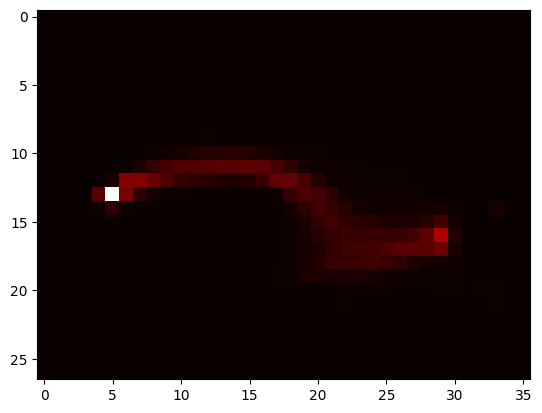

In [158]:
#Setting up for Occupancy Map
fig,ax = plt.subplots()
data = long.loc[(long['odd']=='right') & (long['wall']=='noise')&(long['start']=='bottom')]

top_x = np.concatenate(data.ts_nose_x.to_numpy())
top_y = np.concatenate(data.ts_nose_y.to_numpy())
XsizeOfVideo = 720
YsizeOfVideo = 540
samplingRate = 60
scaleForRateMap = 20
binXForRateMap = XsizeOfVideo / scaleForRateMap
binYForRateMap = YsizeOfVideo / scaleForRateMap
occMat = []
occMat = np.zeros(((int(binYForRateMap)), int(binXForRateMap)))
occMat[occMat < 0.0001] = float("NaN")
for i in range(0,int(binXForRateMap)):
    for j in range(0,int(binYForRateMap)):
        occForBin = (((top_x  < (i*scaleForRateMap)) & (top_x > ((i-1)*scaleForRateMap))) & ((top_y < (j*scaleForRateMap)) & (top_y > ((j-1)*scaleForRateMap)))) .sum()
        occMat[j][i]= occForBin 
        occForBin = []
#visualize occupancy map


#plot_arena(data,ax)

ax.imshow(occMat
, cmap = 'hot')

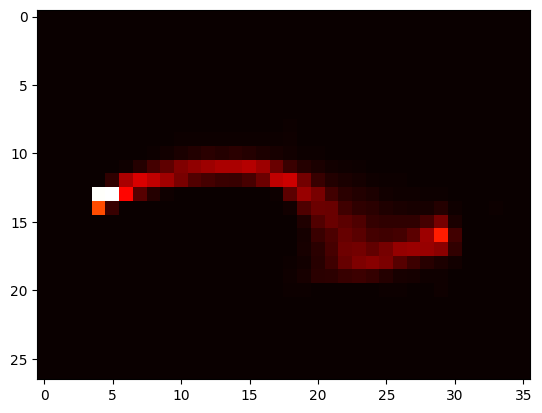

In [157]:
#Setting up for Occupancy Map
fig,ax = plt.subplots()
data = long.loc[(long['odd']=='right') & (long['wall']=='white')&(long['start']=='bottom')]

top_x = np.concatenate(data.ts_nose_x.to_numpy())
top_y = np.concatenate(data.ts_nose_y.to_numpy())
XsizeOfVideo = 720
YsizeOfVideo = 540
samplingRate = 60
scaleForRateMap = 20
binXForRateMap = XsizeOfVideo / scaleForRateMap
binYForRateMap = YsizeOfVideo / scaleForRateMap
occMat = []
occMat = np.zeros(((int(binYForRateMap)), int(binXForRateMap)))
occMat[occMat < 0.0001] = float("NaN")
for i in range(0,int(binXForRateMap)):
    for j in range(0,int(binYForRateMap)):
        occForBin = (((top_x  < (i*scaleForRateMap)) & (top_x > ((i-1)*scaleForRateMap))) & ((top_y < (j*scaleForRateMap)) & (top_y > ((j-1)*scaleForRateMap)))) .sum()
        occMat[j][i]= occForBin 
        occForBin = []
#visualize occupancy map


#plot_arena(data,ax)

ax.imshow(occMat
, cmap = 'hot')

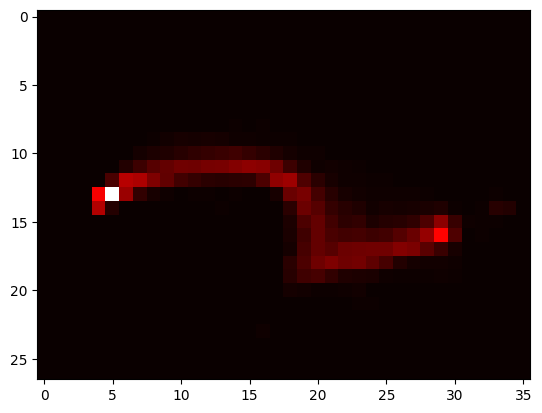

In [156]:
#Setting up for Occupancy Map
fig,ax = plt.subplots()
data = long.loc[(long['odd']=='right') & (long['wall']=='black')&(long['start']=='bottom')]

top_x = np.concatenate(data.ts_nose_x.to_numpy())
top_y = np.concatenate(data.ts_nose_y.to_numpy())
XsizeOfVideo = 720
YsizeOfVideo = 540
samplingRate = 60
scaleForRateMap = 20
binXForRateMap = XsizeOfVideo / scaleForRateMap
binYForRateMap = YsizeOfVideo / scaleForRateMap
occMat = []
occMat = np.zeros(((int(binYForRateMap)), int(binXForRateMap)))
occMat[occMat < 0.0001] = float("NaN")
for i in range(0,int(binXForRateMap)):
    for j in range(0,int(binYForRateMap)):
        occForBin = (((top_x  < (i*scaleForRateMap)) & (top_x > ((i-1)*scaleForRateMap))) & ((top_y < (j*scaleForRateMap)) & (top_y > ((j-1)*scaleForRateMap)))) .sum()
        occMat[j][i]= occForBin 
        occForBin = []
#visualize occupancy map


#plot_arena(data,ax)

ax.imshow(occMat
, cmap = 'hot')

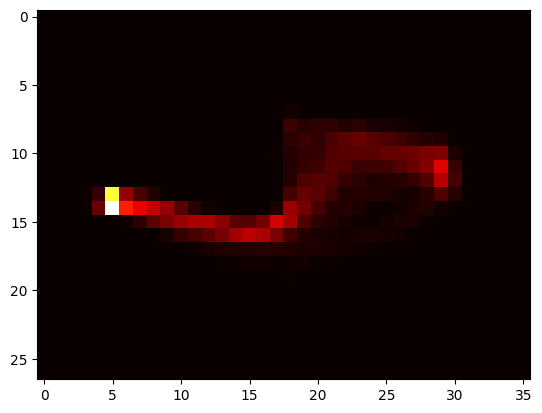

In [152]:
#Setting up for Occupancy Map
fig,ax = plt.subplots()
data = long.loc[(long['odd']=='right') & (long['wall']=='black')&(long['start']=='top')&(long['consecutive']==2)]

top_x = np.concatenate(data.ts_nose_x.to_numpy())
top_y = np.concatenate(data.ts_nose_y.to_numpy())
XsizeOfVideo = 720
YsizeOfVideo = 540
samplingRate = 60
scaleForRateMap = 20
binXForRateMap = XsizeOfVideo / scaleForRateMap
binYForRateMap = YsizeOfVideo / scaleForRateMap
occMat = []
occMat = np.zeros(((int(binYForRateMap)), int(binXForRateMap)))
occMat[occMat < 0.0001] = float("NaN")
for i in range(0,int(binXForRateMap)):
    for j in range(0,int(binYForRateMap)):
        occForBin = (((top_x  < (i*scaleForRateMap)) & (top_x > ((i-1)*scaleForRateMap))) & ((top_y < (j*scaleForRateMap)) & (top_y > ((j-1)*scaleForRateMap)))) .sum()
        occMat[j][i]= occForBin 
        occForBin = []
#visualize occupancy map


#plot_arena(data,ax)

ax.imshow(occMat
, cmap = 'hot')

In [153]:
data

,level_0,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,...,wall_std_interp_ts_nose_y_cm,wall_mad_interp_ts_nose_y_cm,obstacle_mean_interp_ts_nose_y_cm,obstacle_median_interp_ts_nose_y_cm,obstacle_std_interp_ts_nose_y_cm,obstacle_mad_interp_ts_nose_y_cm,condition_mean_interp_ts_nose_y_cm,condition_median_interp_ts_nose_y_cm,condition_std_interp_ts_nose_y_cm,condition_mad_interp_ts_nose_y_cm
13,16,19,45329.628812,45331.279616,"[45329.63872, 45329.655552, 45329.672179, 4532...","[[2727, 2728, 2729, 2730, 2731, 2732, 2733, 27...","[662.4247436523438, 662.3223876953125, 662.512...","[268.860595703125, 267.6027526855469, 266.1972...","[647.87255859375, 648.4732055664062, 648.97534...","[259.42236328125, 258.2563171386719, 256.81088...",...,"[0.9340920238355253, 1.0090738898790987, 1.065...","[0.6101730196452948, 0.6653870442929701, 0.708...","[19.85635146674682, 20.09457132199585, 20.3637...","[19.811777981827674, 20.036769641893763, 20.30...","[0.920678373069903, 0.9882330318872281, 1.0493...","[0.5250046473838221, 0.5266987559991669, 0.556...","[20.2166185024379, 20.437180579660254, 20.7117...","[20.151438834520032, 20.38486919264974, 20.610...","[0.7100621638541298, 0.7778932320928774, 0.836...","[0.47821114215474125, 0.513118354761886, 0.519..."
32,38,41,45378.760268,45380.583091,"[45378.772224, 45378.789875, 45378.805862, 453...","[[5674, 5675, 5676, 5677, 5678, 5679, 5680, 56...","[660.15234375, 661.2433471679688, 661.91552734...","[263.1383361816406, 264.3952941894531, 263.993...","[645.3707885742188, 647.1256103515625, 649.435...","[252.9916229248047, 253.55458068847656, 254.19...",...,"[0.9340920238355253, 1.0090738898790987, 1.065...","[0.6101730196452948, 0.6653870442929701, 0.708...","[19.85635146674682, 20.09457132199585, 20.3637...","[19.811777981827674, 20.036769641893763, 20.30...","[0.920678373069903, 0.9882330318872281, 1.0493...","[0.5250046473838221, 0.5266987559991669, 0.556...","[20.2166185024379, 20.437180579660254, 20.7117...","[20.151438834520032, 20.38486919264974, 20.610...","[0.7100621638541298, 0.7778932320928774, 0.836...","[0.47821114215474125, 0.513118354761886, 0.519..."
53,62,65,45432.586201,45434.556582,"[45432.59104, 45432.60768, 45432.625292, 45432...","[[8902, 8903, 8904, 8905, 8906, 8907, 8908, 89...","[659.2741088867188, 660.4315795898438, 661.183...","[263.6166687011719, 263.93621826171875, 263.68...","[643.8399658203125, 645.242431640625, 646.2151...","[251.87347412109375, 252.78561401367188, 252.6...",...,"[0.9340920238355253, 1.0090738898790987, 1.065...","[0.6101730196452948, 0.6653870442929701, 0.708...","[19.85635146674682, 20.09457132199585, 20.3637...","[19.811777981827674, 20.036769641893763, 20.30...","[0.920678373069903, 0.9882330318872281, 1.0493...","[0.5250046473838221, 0.5266987559991669, 0.556...","[20.2166185024379, 20.437180579660254, 20.7117...","[20.151438834520032, 20.38486919264974, 20.610...","[0.7100621638541298, 0.7778932320928774, 0.836...","[0.47821114215474125, 0.513118354761886, 0.519..."
73,86,91,45492.503398,45494.264883,"[45492.511424, 45492.529292, 45492.545024, 454...","[[12496, 12497, 12498, 12499, 12500, 12501, 12...","[659.7564697265625, 661.1773071289062, 662.333...","[262.91314697265625, 263.3500671386719, 263.73...","[642.7293090820312, 645.2902221679688, 646.848...","[254.25064086914062, 254.33120727539062, 254.2...",...,"[0.9340920238355253, 1.0090738898790987, 1.065...","[0.6101730196452948, 0.6653870442929701, 0.708...","[19.85635146674682, 20.09457132199585, 20.3637...","[19.811777981827674, 20.036769641893763, 20.30...","[0.920678373069903, 0.9882330318872281, 1.0493...","[0.5250046473838221, 0.5266987559991669, 0.556...","[20.2166185024379, 20.437180579660254, 20.7117...","[20.151438834520032, 20.38486919264974, 20.610...","[0.7100621638541298, 0.7778932320928774, 0.836...","[0.47821114215474125, 0.513118354761886, 0.519..."
88,105,111,45538.558476,45540.381350,"[45538.560537, 45538.57719, 45538.5

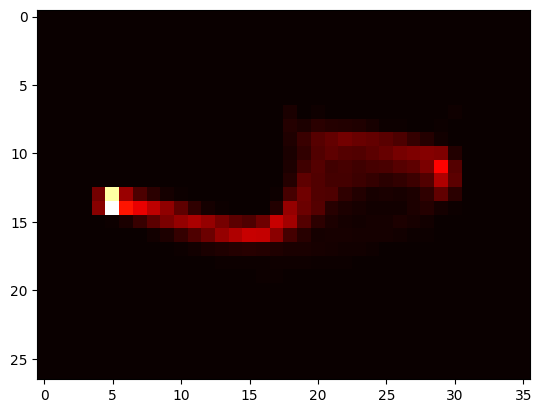

In [154]:
#Setting up for Occupancy Map
fig,ax = plt.subplots()
data = long.loc[(long['odd']=='right') & (long['wall']=='black')&(long['start']=='top')&(long['consecutive']==1)]

top_x = np.concatenate(data.ts_nose_x.to_numpy())
top_y = np.concatenate(data.ts_nose_y.to_numpy())
XsizeOfVideo = 720
YsizeOfVideo = 540
samplingRate = 60
scaleForRateMap = 20
binXForRateMap = XsizeOfVideo / scaleForRateMap
binYForRateMap = YsizeOfVideo / scaleForRateMap
occMat = []
occMat = np.zeros(((int(binYForRateMap)), int(binXForRateMap)))
occMat[occMat < 0.0001] = float("NaN")
for i in range(0,int(binXForRateMap)):
    for j in range(0,int(binYForRateMap)):
        occForBin = (((top_x  < (i*scaleForRateMap)) & (top_x > ((i-1)*scaleForRateMap))) & ((top_y < (j*scaleForRateMap)) & (top_y > ((j-1)*scaleForRateMap)))) .sum()
        occMat[j][i]= occForBin 
        occForBin = []
#visualize occupancy map


#plot_arena(data,ax)

ax.imshow(occMat
, cmap = 'hot')
#plt.plot(np.divide([data.gt_obstacleTL_x.mean(),data.gt_obstacleTR_x.mean(),data.gt_obstacleBR_x.mean(),data.gt_obstacleBL_x.mean(),data.gt_obstacleTL_x.mean()],float(binXForRateMap)),
        #np.divide([data.gt_obstacleTL_y.mean(),data.gt_obstacleTR_y.mean(),data.gt_obstacleBR_y.mean(),data.gt_obstacleBL_y.mean(),data.gt_obstacleTL_y.mean()],float(binYForRateMap)),c='white')





In [155]:
data

,level_0,index,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,...,wall_std_interp_ts_nose_y_cm,wall_mad_interp_ts_nose_y_cm,obstacle_mean_interp_ts_nose_y_cm,obstacle_median_interp_ts_nose_y_cm,obstacle_std_interp_ts_nose_y_cm,obstacle_mad_interp_ts_nose_y_cm,condition_mean_interp_ts_nose_y_cm,condition_median_interp_ts_nose_y_cm,condition_std_interp_ts_nose_y_cm,condition_mad_interp_ts_nose_y_cm
1,1,1,45287.166080,45289.095539,"[45287.173977, 45287.191155, 45287.207692, 452...","[[180, 181, 182, 183, 184, 185, 186, 187, 188,...","[659.1345825195312, 659.9591064453125, 658.926...","[262.79779052734375, 262.86639404296875, 262.2...","[640.8193359375, 642.065185546875, 641.9094848...","[259.280517578125, 258.0514221191406, 258.0626...",...,"[0.9340920238355253, 1.0090738898790987, 1.065...","[0.6101730196452948, 0.6653870442929701, 0.708...","[19.85635146674682, 20.09457132199585, 20.3637...","[19.811777981827674, 20.036769641893763, 20.30...","[0.920678373069903, 0.9882330318872281, 1.0493...","[0.5250046473838221, 0.5266987559991669, 0.556...","[20.2166185024379, 20.437180579660254, 20.7117...","[20.151438834520032, 20.38486919264974, 20.610...","[0.7100621638541298, 0.7778932320928774, 0.836...","[0.47821114215474125, 0.513118354761886, 0.519..."
30,36,39,45373.836518,45375.630643,"[45373.837363, 45373.8539, 45373.870758, 45373...","[[5378, 5379, 5380, 5381, 5382, 5383, 5384, 53...","[658.9888916015625, 659.8367919921875, 660.936...","[262.6311340332031, 262.8354187011719, 262.632...","[643.4417114257812, 645.067626953125, 646.9371...","[251.00555419921875, 250.87335205078125, 250.5...",...,"[0.9340920238355253, 1.0090738898790987, 1.065...","[0.6101730196452948, 0.6653870442929701, 0.708...","[19.85635146674682, 20.09457132199585, 20.3637...","[19.811777981827674, 20.036769641893763, 20.30...","[0.920678373069903, 0.9882330318872281, 1.0493...","[0.5250046473838221, 0.5266987559991669, 0.556...","[20.2166185024379, 20.437180579660254, 20.7117...","[20.151438834520032, 20.38486919264974, 20.610...","[0.7100621638541298, 0.7778932320928774, 0.836...","[0.47821114215474125, 0.513118354761886, 0.519..."
51,60,63,45427.887513,45429.657356,"[45427.889011, 45427.905907, 45427.923353, 454...","[[8620, 8621, 8622, 8623, 8624, 8625, 8626, 86...","[660.4502563476562, 660.454833984375, 661.3882...","[265.1165466308594, 264.84393310546875, 264.86...","[643.5790405273438, 644.8306274414062, 646.271...","[257.3697509765625, 256.9438171386719, 256.507...",...,"[0.9340920238355253, 1.0090738898790987, 1.065...","[0.6101730196452948, 0.6653870442929701, 0.708...","[19.85635146674682, 20.09457132199585, 20.3637...","[19.811777981827674, 20.036769641893763, 20.30...","[0.920678373069903, 0.9882330318872281, 1.0493...","[0.5250046473838221, 0.5266987559991669, 0.556...","[20.2166185024379, 20.437180579660254, 20.7117...","[20.151438834520032, 20.38486919264974, 20.610...","[0.7100621638541298, 0.7778932320928774, 0.836...","[0.47821114215474125, 0.513118354761886, 0.519..."
71,84,89,45488.022041,45489.808089,"[45488.026726, 45488.043609, 45488.06167, 4548...","[[12227, 12228, 12229, 12230, 12231, 12232, 12...","[660.894287109375, 661.5049438476562, 661.3256...","[267.4952087402344, 267.081787109375, 265.6828...","[644.6748046875, 645.6123657226562, 646.082153...","[259.82525634765625, 258.6837158203125, 257.28...",...,"[0.9340920238355253, 1.0090738898790987, 1.065...","[0.6101730196452948, 0.6653870442929701, 0.708...","[19.85635146674682, 20.09457132199585, 20.3637...","[19.811777981827674, 20.036769641893763, 20.30...","[0.920678373069903, 0.9882330318872281, 1.0493...","[0.5250046473838221, 0.5266987559991669, 0.556...","[20.2166185024379, 20.437180579660254, 20.7117...","[20.151438834520032, 20.38486919264974, 20.610...","[0.7100621638541298, 0.7778932320928774, 0.836...","[0.47821114215474125, 0.513118354761886, 0.519..."
105,124,133,45591.729088,45593.364134,"[45591.729292, 45591.74624, 45591.762

In [147]:
print(data.arenaBL_x,data.arenaBL_y)

1        [43.50470733642578, 43.7209587097168, 42.50335...
13       [41.33364486694336, 41.44607162475586, 40.3252...
30       [45.79777145385742, 45.705543518066406, 45.585...
32       [40.6104621887207, 40.219482421875, 39.5725021...
51       [46.76234817504883, 45.91592788696289, 45.6771...
                               ...                        
31501    [44.51802062988281, 45.20283508300781, 43.9131...
31513    [45.748600006103516, 44.526737213134766, 47.00...
31515    [44.06513214111328, 45.63726806640625, 45.9412...
31525    [44.04492950439453, 43.87588882446289, 43.8351...
31575    [44.57564926147461, 45.19268798828125, 44.3352...
Name: arenaBL_x, Length: 617, dtype: object 1        [438.6224670410156, 438.1188659667969, 438.052...
13       [438.54486083984375, 438.83258056640625, 439.2...
30       [438.62493896484375, 438.7492370605469, 439.22...
32       [438.7197570800781, 438.79571533203125, 439.18...
51       [439.3317565917969, 439.04107666015625, 439.16...
            

In [145]:
print(data.arenaTL_x,data.arenaTL_y)

1        [49.70824432373047, 49.56291961669922, 49.5439...
13       [49.64702606201172, 48.69428253173828, 49.6008...
30       [47.86640930175781, 48.0689697265625, 48.55647...
32       [50.92311477661133, 49.63897705078125, 49.4174...
51       [48.977256774902344, 48.11036682128906, 47.346...
                               ...                        
31501    [57.515342712402344, 56.0544319152832, 55.2686...
31513    [57.58089065551758, 55.742103576660156, 56.033...
31515    [57.93221664428711, 58.23451232910156, 58.9770...
31525    [57.47199630737305, 55.678314208984375, 55.290...
31575    [54.7790641784668, 56.135215759277344, 55.2021...
Name: arenaTL_x, Length: 617, dtype: object 1        [99.95206451416016, 100.06730651855469, 99.422...
13       [98.52365112304688, 98.44056701660156, 99.5253...
30       [100.75492095947266, 100.1817398071289, 100.61...
32       [99.81082153320312, 99.20489501953125, 98.3440...
51       [101.40122985839844, 101.6191177368164, 101.77...
            

In [139]:
occMat[10]

array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   9.,  88., 172., 254., 335.,
       314., 318., 338., 383., 430., 464., 498., 496.,  97.,   0.,   0.,
         0.,   0.,   0.])

In [135]:
occMat[10]

array([   0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,  117.74811593, 1151.31491136, 2250.29732674,
       3323.11349414, 4382.84653755, 4108.1009337 , 4160.43342968,
       4422.09590953, 5010.8364892 , 5625.74331686, 6070.56953261,
       6515.39574836, 6489.22950037, 1269.06302729,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ])

In [134]:
occMat[j][i]

0.0

In [ ]:
#Setting up for Occupancy Map
data = long.loc[(long['odd']=='left') & (long['wall']=='black')&(long['start']=='top')]

top_x = np.concatenate(data.ts_nose_x.to_numpy())
top_y = np.concatenate(data.ts_nose_y.to_numpy())
XsizeOfVideo = 720
YsizeOfVideo = 540
samplingRate = 60
scaleForRateMap = 20
binXForRateMap = XsizeOfVideo / scaleForRateMap
binYForRateMap = YsizeOfVideo / scaleForRateMap
occMat = []
occMat = np.zeros(((int(binYForRateMap)), int(binXForRateMap)))
occMat[occMat < 0.0001] = float("NaN")
for i in range(0,int(binXForRateMap)):
    for j in range(0,int(binYForRateMap)):
        occForBin = (((top_x < (i*scaleForRateMap)) & (top_x > ((i-1)*scaleForRateMap))) & ((top_y < (j*scaleForRateMap)) & (top_y > ((j-1)*scaleForRateMap)))) .sum()
        occMat[j][i]= occForBin
        occForBin = []
#visualize occupancy map

plt.imshow(occMat, cmap = 'hot')

In [ ]:
data = long.loc[(long['odd']=='right') & (long['wall']=='white')&(long['start']=='top')]
top_x = np.concatenate(data.ts_nose_x.to_numpy())
top_y = np.concatenate(data.ts_nose_y.to_numpy())
XsizeOfVideo = 720
YsizeOfVideo = 540
samplingRate = 60
scaleForRateMap = 20
binXForRateMap = XsizeOfVideo / scaleForRateMap
binYForRateMap = YsizeOfVideo / scaleForRateMap
occMat = []
occMat = np.zeros(((int(binYForRateMap)), int(binXForRateMap)))
occMat[occMat < 0.0001] = float("NaN")
for i in range(0,int(binXForRateMap)):
    for j in range(0,int(binYForRateMap)):
        occForBin = (((top_x < (i*scaleForRateMap)) & (top_x > ((i-1)*scaleForRateMap))) & ((top_y < (j*scaleForRateMap)) & (top_y > ((j-1)*scaleForRateMap)))) .sum()
        occMat[j][i]= occForBin
        occForBin = []
#visualize occupancy map
plt.imshow(occMat, cmap = 'hot',vmin = 100)

In [ ]:
#Setting up for Occupancy Map
data = long.loc[(long['odd']=='left') & (long['wall']=='white')&(long['start']=='top')]

top_x = np.concatenate(data.ts_nose_x.to_numpy())
top_y = np.concatenate(data.ts_nose_y.to_numpy())
XsizeOfVideo = 720
YsizeOfVideo = 540
samplingRate = 60
scaleForRateMap = 20
binXForRateMap = XsizeOfVideo / scaleForRateMap
binYForRateMap = YsizeOfVideo / scaleForRateMap
occMat = []
occMat = np.zeros(((int(binYForRateMap)), int(binXForRateMap)))
occMat[occMat < 0.0001] = float("NaN")
for i in range(0,int(binXForRateMap)):
    for j in range(0,int(binYForRateMap)):
        occForBin = (((top_x < (i*scaleForRateMap)) & (top_x > ((i-1)*scaleForRateMap))) & ((top_y < (j*scaleForRateMap)) & (top_y > ((j-1)*scaleForRateMap)))) .sum()
        occMat[j][i]= occForBin
        occForBin = []
#visualize occupancy map

plt.imshow(occMat, cmap = 'hot')

In [ ]:
#Setting up for Occupancy Map
data = long.loc[(long['odd']=='left') & (long['wall']=='noise')&(long['start']=='top')]

top_x = np.concatenate(data.ts_nose_x.to_numpy())
top_y = np.concatenate(data.ts_nose_y.to_numpy())
XsizeOfVideo = 720
YsizeOfVideo = 540
samplingRate = 60
scaleForRateMap = 20
binXForRateMap = XsizeOfVideo / scaleForRateMap
binYForRateMap = YsizeOfVideo / scaleForRateMap
occMat = []
occMat = np.zeros(((int(binYForRateMap)), int(binXForRateMap)))
occMat[occMat < 0.0001] = float("NaN")
for i in range(0,int(binXForRateMap)):
    for j in range(0,int(binYForRateMap)):
        occForBin = (((top_x < (i*scaleForRateMap)) & (top_x > ((i-1)*scaleForRateMap))) & ((top_y < (j*scaleForRateMap)) & (top_y > ((j-1)*scaleForRateMap)))) .sum()
        occMat[j][i]= occForBin
        occForBin = []
#visualize occupancy map

plt.imshow(occMat, cmap = 'hot')

In [ ]:
data = long.loc[(long['odd']=='right') & (long['wall']=='noise')&(long['start']=='top')]
top_x = np.concatenate(data.ts_nose_x.to_numpy())
top_y = np.concatenate(data.ts_nose_y.to_numpy())
XsizeOfVideo = 720
YsizeOfVideo = 540
samplingRate = 60
scaleForRateMap = 20
binXForRateMap = XsizeOfVideo / scaleForRateMap
binYForRateMap = YsizeOfVideo / scaleForRateMap
occMat = []
occMat = np.zeros(((int(binYForRateMap)), int(binXForRateMap)))
occMat[occMat < 0.0001] = float("NaN")
for i in range(0,int(binXForRateMap)):
    for j in range(0,int(binYForRateMap)):
        occForBin = (((top_x < (i*scaleForRateMap)) & (top_x > ((i-1)*scaleForRateMap))) & ((top_y < (j*scaleForRateMap)) & (top_y > ((j-1)*scaleForRateMap)))) .sum()
        occMat[j][i]= occForBin
        occForBin = []
#visualize occupancy map
plt.imshow(occMat, cmap = 'hot',vmin = 100)

In [ ]:
occMat

In [ ]:
long,short,middle = create_df_by_type(df)

In [ ]:
long

In [ ]:
for ind, row in df.iterrows():
    if row['odd'] == 'left': 
        nose_list = row['nose_x_cm'] 
        odd_ind = np.argmax(nose_list>(df.leftportT_x_cm.unique()+5))
        temp_time = np.diff(row['trial_timestamps'][odd_ind:])
    if row['odd'] == 'right':
        nose_list = row['nose_x_cm'] 
        even_ind = np.argmax(nose_list<(df.rightportT_x_cm.unique()-5))
        temp_time = np.diff(row['trial_timestamps'][even_ind:])
        #temp_time = np.diff(row['trial_timestamps'])
    x = np.diff(row['ts_nose_x_cm']); y = np.diff(row['ts_nose_y_cm'])
    if len(x) == len(temp_time):
        xspeed = list((x/temp_time)**2)
    elif len(x) > len(temp_time):
        xspeed = list((x[:len(temp_time)]/temp_time)**2)
    elif len(x) < len(temp_time):
        xspeed = list((x/temp_time[:len(x)])**2)
    if len(y) == len(temp_time):
        yspeed = list((y/temp_time)**2)
    elif len(y) > len(temp_time):
        yspeed = list((y[:len(temp_time)]/temp_time)**2)
    elif len(y) < len(temp_time):
        yspeed = list((y/temp_time[:len(y)])**2)
    df.at[ind, 'speed']  = np.sqrt(np.sum([xspeed, yspeed],axis=1)).astype(object)
    distance = np.sqrt((x.astype(float))**2) + np.sqrt((y.astype(float))**2)
    df.at[ind, 'distance'] = distance.astype(object)
    df.at[ind, 'total_distance'] = np.nansum(distance).astype(object)

In [ ]:
long_df

In [ ]:
"""Distance from edge light"""
data = long


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=1, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])

ax1 = fig.add_subplot(panel_1[0,0])
ax2 = fig.add_subplot(panel_2[0,0])
ax3 = fig.add_subplot(panel_3[0,0])

ax1.set_ylabel('cm')
ax1.set_xlabel('cm')
ax2.set_ylabel('cm')
ax2.set_xlabel('cm')
ax3.set_ylabel('cm')
ax3.set_xlabel('cm')

for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>-3).max()
    ax1.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'grey',alpha = .5)
ax1.invert_xaxis()
rows = data.shape[0]
angle_array = np.empty([rows,50])
angle_array[:] =np.nan 
distance_array = np.empty([rows,50])
distance_array[:] =np.nan 

for i,row in enumerate(data.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>-3).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['lateral_error'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(-3, 17, .4)
    ynew = interpolater(xnew)
    distance_array[i] = xnew
    angle_array[i] = ynew
    ax2.plot(xnew,ynew,c = 'grey',alpha = .5)
ax2.invert_xaxis()
print(distance_array.shape,angle_array.shape)
ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
print(np.nanmedian(angle_array,axis = 0).max())
by_consecutive = data.groupby(['consecutive'])
for con,con_df in by_consecutive:
    if con == 1:
        first_df = con_df
    if con ==2:
        sec_df = con_df
rows = first_df.shape[0]
angle_array = np.empty([rows,50])
angle_array[:] =np.nan 
distance_array = np.empty([rows,50])
distance_array[:] =np.nan 
for i,row in enumerate(first_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>-3).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['lateral_error'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(-3, 17, .4)
    ynew = interpolater(xnew)
    distance_array[i] = xnew
    angle_array[i] = ynew
    ax3.plot(xnew,ynew,c = 'red',alpha = .01)
ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'purple',label = 'first')
print(distance_array.shape,angle_array.shape)
rows = sec_df.shape[0]
angle_array_sec = np.empty([rows,50])
angle_array_sec[:] =np.nan 
distance_array_sec = np.empty([rows,50])
distance_array_sec[:] =np.nan 
for i,row in enumerate(sec_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>-3).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['lateral_error'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(-3, 17, .4)
    ynew = interpolater(xnew)
    distance_array_sec[i] = xnew
    angle_array_sec[i] = ynew
    ax3.plot(xnew,ynew,c = 'blue',alpha = .01)
ax3.plot(np.nanmedian(distance_array_sec,axis = 0),np.nanmedian(angle_array_sec,axis = 0),c = 'black',label = 'seconed')
print(distance_array_sec.shape,angle_array_sec.shape)
ax3.invert_xaxis()
ax3.legend()
symmetrize_y_axis(ax1)
symmetrize_y_axis(ax2)
symmetrize_y_axis(ax3)

In [16]:
def drop_nans_in_columns(df,column):
    copy =df.copy(deep=True) 
    nan_inds = copy.index[np.where(copy[column].isnull())[0]]
    copy = copy.drop(index=nan_inds)
    return copy

In [ ]:
data = drop_nans_in_columns(long,'lateral_error')


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=1, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])

ax1 = fig.add_subplot(panel_1[0,0])
ax2 = fig.add_subplot(panel_2[0,0])
ax3 = fig.add_subplot(panel_3[0,0])

ax1.set_ylabel('cm')
ax1.set_xlabel('cm')
ax2.set_ylabel('cm')
ax2.set_xlabel('cm')
ax3.set_ylabel('cm')
ax3.set_xlabel('cm')

for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>-3).max()
    if row['wall'] == 'black':
        ax1.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'black',alpha = .5)
    if row['wall'] == 'white':
        ax1.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'red',alpha = .5)
    if row['wall'] == 'noise':
        ax1.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'blue',alpha = .5)
    
ax1.invert_xaxis()


for wall, wall_frame in data.groupby(['wall']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>-3).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['lateral_error'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha = .5)

    if row[1]['wall'] == 'black':
        #distance_array = reject_outliers(distance_array)
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        
    if row[1]['wall'] == 'white':
        #distance_array = reject_outliers(distance_array)
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
    
    if row[1]['wall'] == 'noise':
        #distance_array = reject_outliers(distance_array)
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
    
ax2.invert_xaxis()

symmetrize_y_axis(ax1)
symmetrize_y_axis(ax2)
 

In [ ]:
x =remove_outliers(angle_array)

In [ ]:
angle_array.shape

In [ ]:
x.shape

In [ ]:
distance_array

In [ ]:
long.ts_nose_x

In [ ]:
array_reject_outliers(angle_array)

In [ ]:

def array_remove_outliers(arr, threshold=3):
    """
    Remove outlier vectors from an array of vectors using Z-score.

    Parameters:
    - arr: 2D numpy array where each row represents a vector.
    - threshold: Z-score threshold for identifying outliers. Default is 3.

    Returns:
    - A new array without outlier vectors.
    """

    # Calculate the mean and standard deviation along each dimension
    mean = np.nanmean(arr, axis=0)
    std = np.nanstd(arr, axis=0)

    # Calculate Z-scores for each element in the array
    z_scores = np.abs((arr - mean) / std)

    # Create a boolean mask to identify outliers
    outlier_mask = (z_scores <= threshold).all(axis=1)

    # Filter the array to keep only non-outlier vectors
    filtered_arr = arr[outlier_mask]

    return filtered_arr,outlier_mask,z_scores

In [ ]:
def reject_outliers(data, m = 2):
    d = np.abs(data - np.median(data))
    mdev = np.median(d)
    s = d/mdev if mdev else np.zeros(len(d))
    #inds = np.argwhere(data[s<m])
    return data[s<m]

In [ ]:
fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=2, figure=fig)

In [ ]:
angle_array

In [ ]:
data = drop_nans_in_columns(long,'lateral_error')


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=1, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])

ax1 = fig.add_subplot(panel_1[0,0])
ax2 = fig.add_subplot(panel_2[0,0])
ax3 = fig.add_subplot(panel_3[0,0])

ax1.set_ylabel('cm')
ax1.set_xlabel('cm')
ax2.set_ylabel('cm')
ax2.set_xlabel('cm')
ax3.set_ylabel('cm')
ax3.set_xlabel('cm')

for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>-3).max()
    if row['wall'] == 'black':
        ax1.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'black',alpha = .5)
    if row['wall'] == 'white':
        ax1.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'red',alpha = .5)
    if row['wall'] == 'noise':
        ax1.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'blue',alpha = .5)
    
ax1.invert_xaxis()


for wall, wall_frame in data.groupby(['obstalce']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>-3).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['lateral_error'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha = .5)

    if row[1]['wall'] == 'black':
        #distance_array = reject_outliers(distance_array)
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        
    if row[1]['wall'] == 'white':
        #distance_array = reject_outliers(distance_array)
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
    
    if row[1]['wall'] == 'noise':
        #distance_array = reject_outliers(distance_array)
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
    
ax2.invert_xaxis()

symmetrize_y_axis(ax1)
symmetrize_y_axis(ax2)

In [ ]:
data = drop_nans_in_columns(long,'lateral_error')



fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=3, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])
panel_4 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[3])
panel_5 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[4])
panel_6 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[5])
panel_7 = gridspec.GridSpecFromSubplotSpec(2,4,subplot_spec=spec2[7])

ax1 = fig.add_subplot(panel_1[0:,0])
ax2 = fig.add_subplot(panel_2[0:,0])
ax3 = fig.add_subplot(panel_3[0:,0])
ax4 = fig.add_subplot(panel_4[0:,0])
ax5 = fig.add_subplot(panel_5[0:,0])
ax6 = fig.add_subplot(panel_6[0:,0])
ax7 = fig.add_subplot(panel_7[0:, 0:4])


ax1.set_ylabel('cm')
ax1.set_xlabel('cm')

ax2.set_ylabel('cm')
ax2.set_xlabel('cm')


ax3.set_ylabel('cm')
ax3.set_xlabel('cm')

ax4.set_ylabel('cm')
ax4.set_xlabel('cm')
ax4.set_ylim(top=10,bottom=-10)


ax5.set_ylabel('cm')
ax5.set_xlabel('cm')
ax5.set_ylim(top=10,bottom=-10)


ax6.set_ylabel('cm')
ax6.set_xlabel('cm')
ax6.set_ylim(top=10,bottom=-10)


ax7.set_ylabel('cm')
ax7.set_xlabel('cm')

for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>-3).max()
    if row['obstalce'] == 'black':
        ax4.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'black',alpha =.1)
    if row['obstalce'] == 'white':
        ax5.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'red',alpha =.2)
    if row['obstalce'] == 'noise':
        ax6.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'blue',alpha =.2)
    
ax1.invert_xaxis()
ax2.invert_xaxis()
ax3.invert_xaxis()
ax4.invert_xaxis()
ax5.invert_xaxis()
ax6.invert_xaxis()
ax7.invert_xaxis()

for obstalce, obstalce_frame in data.groupby(['obstalce']):
    rows = obstalce_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(obstalce_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>-3).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['lateral_error'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha =.2)

    if row[1]['obstalce'] == 'black':
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        std_trace = np.nanstd(angle_array,axis=0)
        ax1.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        ax1.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='grey', alpha=1)
        #right_obstalce_axis.fill_between(np.linspace(10,50,50), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='black', alpha=0.5)
    if row[1]['obstalce'] == 'white':
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        std_trace = np.nanstd(angle_array,axis=0)
        ax2.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='red', alpha=.5)
    
    if row[1]['obstalce'] == 'noise':
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        std_trace = np.nanstd(angle_array,axis=0)
        ax3.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='blue', alpha=.5)

In [ ]:
data = drop_nans_in_columns(long,'lateral_error')
data = data.loc[data['odd']=='left']



fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=3, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])
panel_4 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[3])
panel_5 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[4])
panel_6 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[5])
panel_7 = gridspec.GridSpecFromSubplotSpec(2,4,subplot_spec=spec2[7])

ax1 = fig.add_subplot(panel_1[0:,0])
ax2 = fig.add_subplot(panel_2[0:,0])
ax3 = fig.add_subplot(panel_3[0:,0])
ax4 = fig.add_subplot(panel_4[0:,0])
ax5 = fig.add_subplot(panel_5[0:,0])
ax6 = fig.add_subplot(panel_6[0:,0])
ax7 = fig.add_subplot(panel_7[0:, 0:4])


ax1.set_ylabel('cm')
ax1.set_xlabel('cm')

ax2.set_ylabel('cm')
ax2.set_xlabel('cm')


ax3.set_ylabel('cm')
ax3.set_xlabel('cm')

ax4.set_ylabel('cm')
ax4.set_xlabel('cm')
ax4.set_ylim(top=10,bottom=-10)


ax5.set_ylabel('cm')
ax5.set_xlabel('cm')
ax5.set_ylim(top=10,bottom=-10)


ax6.set_ylabel('cm')
ax6.set_xlabel('cm')
ax6.set_ylim(top=10,bottom=-10)


ax7.set_ylabel('cm')
ax7.set_xlabel('cm')

for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>-3).max()
    if row['obstalce'] == 'black':
        ax4.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'black',alpha =.1)
    if row['obstalce'] == 'white':
        ax5.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'red',alpha =.2)
    if row['obstalce'] == 'noise':
        ax6.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'blue',alpha =.2)
    
ax1.invert_xaxis()
ax2.invert_xaxis()
ax3.invert_xaxis()
ax4.invert_xaxis()
ax5.invert_xaxis()
ax6.invert_xaxis()
ax7.invert_xaxis()

for obstalce, obstalce_frame in data.groupby(['obstalce']):
    rows = obstalce_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(obstalce_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>-3).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['lateral_error'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha =.2)

    if row[1]['obstalce'] == 'black':
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        std_trace = np.nanstd(angle_array,axis=0)
        ax1.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        ax1.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='grey', alpha=1)
        #right_obstalce_axis.fill_between(np.linspace(10,50,50), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='black', alpha=0.5)
    if row[1]['obstalce'] == 'white':
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        std_trace = np.nanstd(angle_array,axis=0)
        ax2.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='red', alpha=.5)
    
    if row[1]['obstalce'] == 'noise':
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        std_trace = np.nanstd(angle_array,axis=0)
        ax3.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='blue', alpha=.5)

In [ ]:
data = drop_nans_in_columns(long,'lateral_error')
data = data.loc[data['odd']=='right']



fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=3, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])
panel_4 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[3])
panel_5 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[4])
panel_6 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[5])
panel_7 = gridspec.GridSpecFromSubplotSpec(2,4,subplot_spec=spec2[7])

ax1 = fig.add_subplot(panel_1[0:,0])
ax2 = fig.add_subplot(panel_2[0:,0])
ax3 = fig.add_subplot(panel_3[0:,0])
ax4 = fig.add_subplot(panel_4[0:,0])
ax5 = fig.add_subplot(panel_5[0:,0])
ax6 = fig.add_subplot(panel_6[0:,0])
ax7 = fig.add_subplot(panel_7[0:, 0:4])


ax1.set_ylabel('cm')
ax1.set_xlabel('cm')

ax2.set_ylabel('cm')
ax2.set_xlabel('cm')


ax3.set_ylabel('cm')
ax3.set_xlabel('cm')

ax4.set_ylabel('cm')
ax4.set_xlabel('cm')
ax4.set_ylim(top=10,bottom=-10)


ax5.set_ylabel('cm')
ax5.set_xlabel('cm')
ax5.set_ylim(top=10,bottom=-10)
ax5.set_xlim(left = -5,right = 25)


ax6.set_ylabel('cm')
ax6.set_xlabel('cm')
ax6.set_ylim(top=10,bottom=-10)


ax7.set_ylabel('cm')
ax7.set_xlabel('cm')

for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>-3).max()
    if row['obstalce'] == 'black':
        ax4.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'black',alpha =.1)
    if row['obstalce'] == 'white':
        ax5.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'red',alpha =.2)
    if row['obstalce'] == 'noise':
        ax6.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'blue',alpha =.2)
    
ax1.invert_xaxis()
ax2.invert_xaxis()
ax3.invert_xaxis()
ax4.invert_xaxis()
ax5.invert_xaxis()
ax6.invert_xaxis()
ax7.invert_xaxis()

for obstalce, obstalce_frame in data.groupby(['obstalce']):
    rows = obstalce_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(obstalce_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>-3).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['lateral_error'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha =.2)

    if row[1]['obstalce'] == 'black':
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        std_trace = np.nanstd(angle_array,axis=0)
        ax1.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        ax1.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='grey', alpha=1)
        #right_obstalce_axis.fill_between(np.linspace(10,50,50), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='black', alpha=0.5)
    if row[1]['obstalce'] == 'white':
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        std_trace = np.nanstd(angle_array,axis=0)
        ax2.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='red', alpha=.5)
    
    if row[1]['obstalce'] == 'noise':
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        std_trace = np.nanstd(angle_array,axis=0)
        ax3.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='blue', alpha=.5)

In [ ]:
data = drop_nans_in_columns(long,'lateral_error')



fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=3, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])
panel_4 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[3])
panel_5 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[4])
panel_6 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[5])
panel_7 = gridspec.GridSpecFromSubplotSpec(2,4,subplot_spec=spec2[7])

ax1 = fig.add_subplot(panel_1[0:,0])
ax2 = fig.add_subplot(panel_2[0:,0])
ax3 = fig.add_subplot(panel_3[0:,0])
ax4 = fig.add_subplot(panel_4[0:,0])
ax5 = fig.add_subplot(panel_5[0:,0])
ax6 = fig.add_subplot(panel_6[0:,0])
ax7 = fig.add_subplot(panel_7[0:, 0:4])


ax1.set_ylabel('cm')
ax1.set_xlabel('cm')

ax2.set_ylabel('cm')
ax2.set_xlabel('cm')


ax3.set_ylabel('cm')
ax3.set_xlabel('cm')

ax4.set_ylabel('cm')
ax4.set_xlabel('cm')
ax4.set_ylim(top=10,bottom=-10)


ax5.set_ylabel('cm')
ax5.set_xlabel('cm')
ax5.set_ylim(top=10,bottom=-10)


ax6.set_ylabel('cm')
ax6.set_xlabel('cm')
ax6.set_ylim(top=10,bottom=-10)


ax7.set_ylabel('cm')
ax7.set_xlabel('cm')

for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>-3).max()
    if row['wall'] == 'black':
        ax4.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'black',alpha =.1)
    if row['wall'] == 'white':
        ax5.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'red',alpha =.2)
    if row['wall'] == 'noise':
        ax6.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'blue',alpha =.2)
    
ax1.invert_xaxis()
ax2.invert_xaxis()
ax3.invert_xaxis()
ax4.invert_xaxis()
ax5.invert_xaxis()
ax6.invert_xaxis()
ax7.invert_xaxis()

for wall, wall_frame in data.groupby(['wall']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>-3).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['lateral_error'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha =.2)

    if row[1]['wall'] == 'black':
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        std_trace = np.nanstd(angle_array,axis=0)
        ax1.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        ax1.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='grey', alpha=1)
        #right_obstacle_axis.fill_between(np.linspace(10,50,50), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='black', alpha=0.5)
    if row[1]['wall'] == 'white':
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        std_trace = np.nanstd(angle_array,axis=0)
        ax2.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='red', alpha=.5)
    
    if row[1]['wall'] == 'noise':
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        std_trace = np.nanstd(angle_array,axis=0)
        ax3.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='blue', alpha=.5)


In [ ]:
data = drop_nans_in_columns(long,'zero_out_angle_to_corner')
data = data.loc[data['odd']=='left']


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=3, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])
panel_4 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[3])
panel_5 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[4])
panel_6 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[5])
panel_7 = gridspec.GridSpecFromSubplotSpec(2,4,subplot_spec=spec2[7])

ax1 = fig.add_subplot(panel_1[0:,0])
ax2 = fig.add_subplot(panel_2[0:,0])
ax3 = fig.add_subplot(panel_3[0:,0])
ax4 = fig.add_subplot(panel_4[0:,0])
ax5 = fig.add_subplot(panel_5[0:,0])
ax6 = fig.add_subplot(panel_6[0:,0])
ax7 = fig.add_subplot(panel_7[0:, 0:4])


ax1.set_ylabel('deg')
ax1.set_xlabel('cm')
ax1.set_ylim(top=180,bottom=0)
ax2.set_ylabel('deg')
ax2.set_xlabel('cm')
ax2.set_ylim(top=180,bottom=0)
ax3.set_ylabel('deg')
ax3.set_xlabel('cm')
ax3.set_ylim(top=180,bottom=0)
ax4.set_ylabel('deg')
ax4.set_xlabel('cm')
ax4.set_xlim(right=25,left=0)
ax4.set_ylim(top=180,bottom=0)
ax5.set_ylabel('deg')
ax5.set_xlabel('cm')
ax5.set_xlim(right=25,left=0)
ax5.set_ylim(top=180,bottom=0)
ax6.set_ylabel('deg')
ax6.set_xlabel('cm')
ax6.set_xlim(right=25,left=0)
ax6.set_ylim(top=180,bottom=0)
ax7.set_ylabel('deg')
ax7.set_xlabel('cm')
ax7.set_ylim(top=180,bottom=0)


for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>1).max()
    if row['wall'] == 'black':
        ax4.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'black',alpha =.1)
    if row['wall'] == 'white':
        ax5.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'red',alpha =.2)
    if row['wall'] == 'noise':
        ax6.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'blue',alpha =.2)
    
ax1.invert_xaxis()
ax2.invert_xaxis()
ax3.invert_xaxis()
ax4.invert_xaxis()
ax5.invert_xaxis()
ax6.invert_xaxis()
ax7.invert_xaxis()


for wall, wall_frame in data.groupby(['wall']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>1).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha =.2)

    if wall_frame['wall'].unique() == 'black':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        std_trace = np.nanstd(angle_array,axis=0)
        ax1.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        ax1.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='grey', alpha=1)
        #right_obstacle_axis.fill_between(np.linspace(10,50,50), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='black', alpha=0.5)
    if wall_frame['wall'].unique() == 'white':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        std_trace = np.nanstd(angle_array,axis=0)
        ax2.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='red', alpha=.5)
    
    if wall_frame['wall'].unique() == 'noise':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        std_trace = np.nanstd(angle_array,axis=0)
        ax3.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='blue', alpha=.5)

1007
1040
862


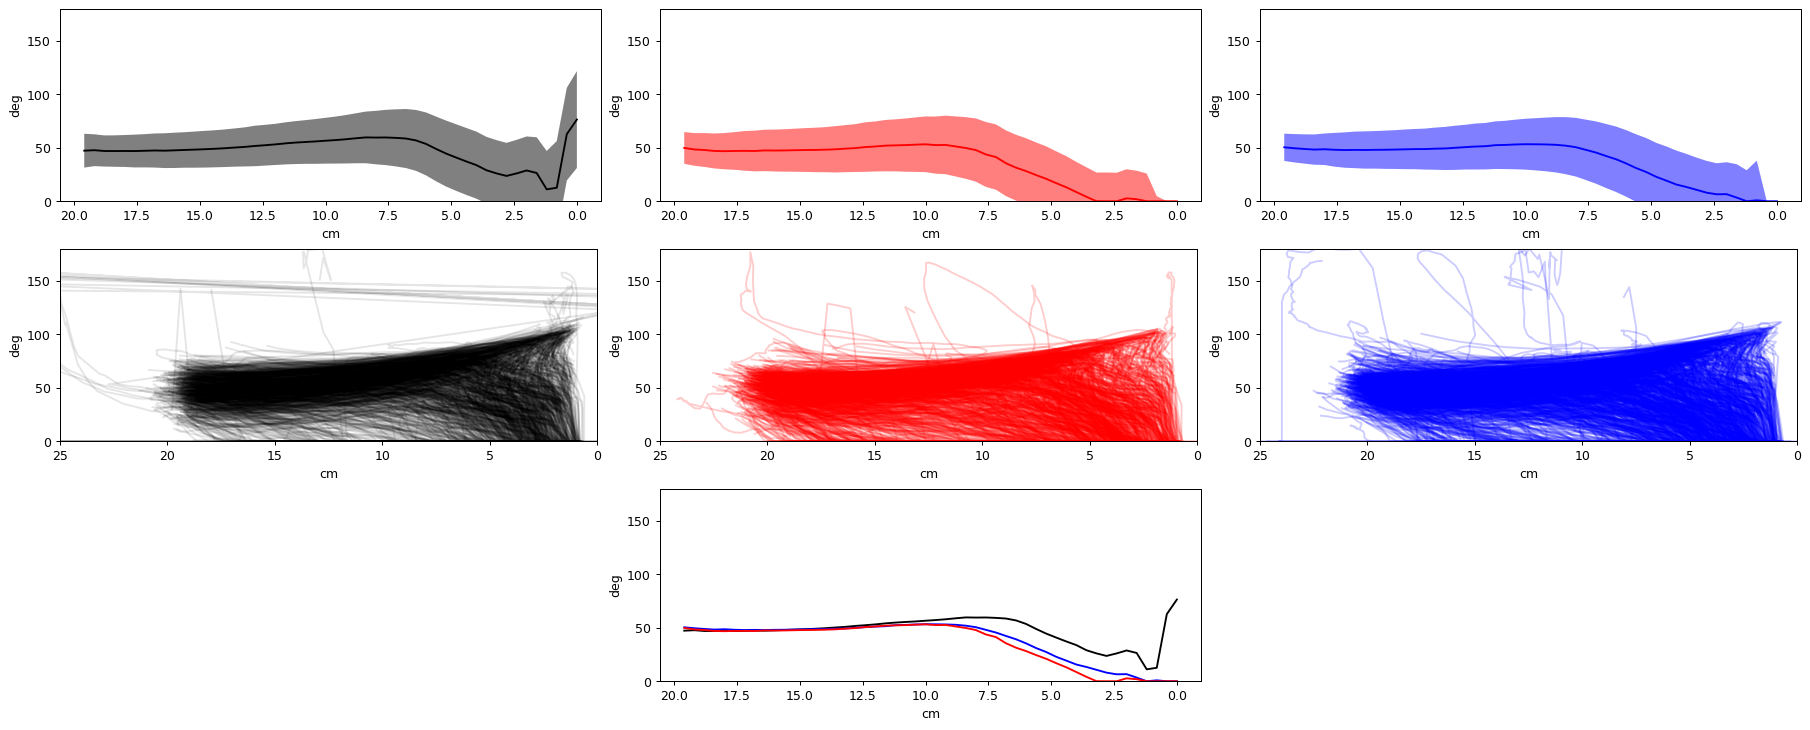

In [17]:
data = drop_nans_in_columns(long,'zero_out_angle_to_corner')
data = data.loc[data['odd']=='right']


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=3, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])
panel_4 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[3])
panel_5 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[4])
panel_6 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[5])
panel_7 = gridspec.GridSpecFromSubplotSpec(2,4,subplot_spec=spec2[7])

ax1 = fig.add_subplot(panel_1[0:,0])
ax2 = fig.add_subplot(panel_2[0:,0])
ax3 = fig.add_subplot(panel_3[0:,0])
ax4 = fig.add_subplot(panel_4[0:,0])
ax5 = fig.add_subplot(panel_5[0:,0])
ax6 = fig.add_subplot(panel_6[0:,0])
ax7 = fig.add_subplot(panel_7[0:, 0:4])


ax1.set_ylabel('deg')
ax1.set_xlabel('cm')
ax1.set_ylim(top=180,bottom=0)
ax2.set_ylabel('deg')
ax2.set_xlabel('cm')
ax2.set_ylim(top=180,bottom=0)
ax3.set_ylabel('deg')
ax3.set_xlabel('cm')
ax3.set_ylim(top=180,bottom=0)
ax4.set_ylabel('deg')
ax4.set_xlabel('cm')
ax4.set_xlim(right=25,left=0)
ax4.set_ylim(top=180,bottom=0)
ax5.set_ylabel('deg')
ax5.set_xlabel('cm')
ax5.set_xlim(right=25,left=0)
ax5.set_ylim(top=180,bottom=0)
ax6.set_ylabel('deg')
ax6.set_xlabel('cm')
ax6.set_xlim(right=25,left=0)
ax6.set_ylim(top=180,bottom=0)
ax7.set_ylabel('deg')
ax7.set_xlabel('cm')
ax7.set_ylim(top=180,bottom=0)


for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>1).max()
    if row['wall'] == 'black':
        ax4.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'black',alpha =.1)
    if row['wall'] == 'white':
        ax5.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'red',alpha =.2)
    if row['wall'] == 'noise':
        ax6.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'blue',alpha =.2)
    
ax1.invert_xaxis()
ax2.invert_xaxis()
ax3.invert_xaxis()
ax4.invert_xaxis()
ax5.invert_xaxis()
ax6.invert_xaxis()
ax7.invert_xaxis()


for wall, wall_frame in data.groupby(['wall']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>1).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha =.2)

    if wall_frame['wall'].unique() == 'black':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        std_trace = np.nanstd(angle_array,axis=0)
        ax1.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        ax1.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='grey', alpha=1)
        #right_obstacle_axis.fill_between(np.linspace(10,50,50), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='black', alpha=0.5)
    if wall_frame['wall'].unique() == 'white':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        std_trace = np.nanstd(angle_array,axis=0)
        ax2.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='red', alpha=.5)
    
    if wall_frame['wall'].unique() == 'noise':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        std_trace = np.nanstd(angle_array,axis=0)
        ax3.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='blue', alpha=.5)

In [15]:
data = drop_nans_in_columns(long,'zero_out_angle_to_corner')


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=3, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])
panel_4 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[3])
panel_5 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[4])
panel_6 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[5])
panel_7 = gridspec.GridSpecFromSubplotSpec(2,4,subplot_spec=spec2[7])

ax1 = fig.add_subplot(panel_1[0:,0])
ax2 = fig.add_subplot(panel_2[0:,0])
ax3 = fig.add_subplot(panel_3[0:,0])
ax4 = fig.add_subplot(panel_4[0:,0])
ax5 = fig.add_subplot(panel_5[0:,0])
ax6 = fig.add_subplot(panel_6[0:,0])
ax7 = fig.add_subplot(panel_7[0:, 0:4])


ax1.set_ylabel('deg')
ax1.set_xlabel('cm')
ax1.set_ylim(top=180,bottom=0)
ax2.set_ylabel('deg')
ax2.set_xlabel('cm')
ax2.set_ylim(top=180,bottom=0)
ax3.set_ylabel('deg')
ax3.set_xlabel('cm')
ax3.set_ylim(top=180,bottom=0)
ax4.set_ylabel('deg')
ax4.set_xlabel('cm')
ax4.set_xlim(right=25,left=0)
ax4.set_ylim(top=180,bottom=0)
ax5.set_ylabel('deg')
ax5.set_xlabel('cm')
ax5.set_xlim(right=25,left=0)
ax5.set_ylim(top=180,bottom=0)
ax6.set_ylabel('deg')
ax6.set_xlabel('cm')
ax6.set_xlim(right=25,left=0)
ax6.set_ylim(top=180,bottom=0)
ax7.set_ylabel('deg')
ax7.set_xlabel('cm')
ax7.set_ylim(top=180,bottom=0)


for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>1).max()
    if row['wall'] == 'black':
        ax4.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'black',alpha =.1)
    if row['wall'] == 'white':
        ax5.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'red',alpha =.2)
    if row['wall'] == 'noise':
        ax6.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'blue',alpha =.2)
    
ax1.invert_xaxis()
ax2.invert_xaxis()
ax3.invert_xaxis()
ax4.invert_xaxis()
ax5.invert_xaxis()
ax6.invert_xaxis()
ax7.invert_xaxis()


for wall, wall_frame in data.groupby(['wall']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>1).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha =.2)

    if wall_frame['wall'].unique() == 'black':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        std_trace = np.nanstd(angle_array,axis=0)
        ax1.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        ax1.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='grey', alpha=1)
        #right_obstacle_axis.fill_between(np.linspace(10,50,50), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='black', alpha=0.5)
    if wall_frame['wall'].unique() == 'white':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        std_trace = np.nanstd(angle_array,axis=0)
        ax2.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='red', alpha=.5)
    
    if wall_frame['wall'].unique() == 'noise':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        std_trace = np.nanstd(angle_array,axis=0)
        ax3.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='blue', alpha=.5)

 





NameError: name 'drop_nans_in_columns' is not defined

In [ ]:
data = drop_nans_in_columns(long,'zero_out_angle_to_corner')
data = data.loc[data['odd']=='right']


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=3, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])
panel_4 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[3])
panel_5 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[4])
panel_6 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[5])
panel_7 = gridspec.GridSpecFromSubplotSpec(2,4,subplot_spec=spec2[7])

ax1 = fig.add_subplot(panel_1[0:,0])
ax2 = fig.add_subplot(panel_2[0:,0])
ax3 = fig.add_subplot(panel_3[0:,0])
ax4 = fig.add_subplot(panel_4[0:,0])
ax5 = fig.add_subplot(panel_5[0:,0])
ax6 = fig.add_subplot(panel_6[0:,0])
ax7 = fig.add_subplot(panel_7[0:, 0:4])


ax1.set_ylabel('deg')
ax1.set_xlabel('cm')
ax1.set_ylim(top=180,bottom=0)
ax2.set_ylabel('deg')
ax2.set_xlabel('cm')
ax2.set_ylim(top=180,bottom=0)
ax3.set_ylabel('deg')
ax3.set_xlabel('cm')
ax3.set_ylim(top=180,bottom=0)
ax4.set_ylabel('deg')
ax4.set_xlabel('cm')
ax4.set_xlim(right=25,left=0)
ax4.set_ylim(top=180,bottom=0)
ax5.set_ylabel('deg')
ax5.set_xlabel('cm')
ax5.set_xlim(right=25,left=0)
ax5.set_ylim(top=180,bottom=0)
ax6.set_ylabel('deg')
ax6.set_xlabel('cm')
ax6.set_xlim(right=25,left=0)
ax6.set_ylim(top=180,bottom=0)
ax7.set_ylabel('deg')
ax7.set_xlabel('cm')
ax7.set_ylim(top=180,bottom=0)


for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>1).max()
    if row['wall'] == 'black':
        ax4.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'black',alpha =.1)
    if row['wall'] == 'white':
        ax5.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'red',alpha =.2)
    if row['wall'] == 'noise':
        ax6.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'blue',alpha =.2)
    
ax1.invert_xaxis()
ax2.invert_xaxis()
ax3.invert_xaxis()
ax4.invert_xaxis()
ax5.invert_xaxis()
ax6.invert_xaxis()
ax7.invert_xaxis()


for wall, wall_frame in data.groupby(['wall']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>1).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha =.2)

    if wall_frame['wall'].unique() == 'black':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        std_trace = np.nanstd(angle_array,axis=0)
        ax1.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        ax1.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='grey', alpha=1)
        #right_obstacle_axis.fill_between(np.linspace(10,50,50), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='black', alpha=0.5)
    if wall_frame['wall'].unique() == 'white':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        std_trace = np.nanstd(angle_array,axis=0)
        ax2.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='red', alpha=.5)
    
    if wall_frame['wall'].unique() == 'noise':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        std_trace = np.nanstd(angle_array,axis=0)
        ax3.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='blue', alpha=.5)

In [ ]:
data = drop_nans_in_columns(long,'zero_out_angle_to_corner')
data = data.loc[data['odd']=='left']


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=3, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])
panel_4 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[3])
panel_5 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[4])
panel_6 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[5])
panel_7 = gridspec.GridSpecFromSubplotSpec(2,4,subplot_spec=spec2[7])

ax1 = fig.add_subplot(panel_1[0:,0])
ax2 = fig.add_subplot(panel_2[0:,0])
ax3 = fig.add_subplot(panel_3[0:,0])
ax4 = fig.add_subplot(panel_4[0:,0])
ax5 = fig.add_subplot(panel_5[0:,0])
ax6 = fig.add_subplot(panel_6[0:,0])
ax7 = fig.add_subplot(panel_7[0:, 0:4])


ax1.set_ylabel('deg')
ax1.set_xlabel('cm')
ax1.set_ylim(top=180,bottom=0)
ax2.set_ylabel('deg')
ax2.set_xlabel('cm')
ax2.set_ylim(top=180,bottom=0)
ax3.set_ylabel('deg')
ax3.set_xlabel('cm')
ax3.set_ylim(top=180,bottom=0)
ax4.set_ylabel('deg')
ax4.set_xlabel('cm')
ax4.set_xlim(right=25,left=0)
ax4.set_ylim(top=180,bottom=0)
ax5.set_ylabel('deg')
ax5.set_xlabel('cm')
ax5.set_xlim(right=25,left=0)
ax5.set_ylim(top=180,bottom=0)
ax6.set_ylabel('deg')
ax6.set_xlabel('cm')
ax6.set_xlim(right=25,left=0)
ax6.set_ylim(top=180,bottom=0)
ax7.set_ylabel('deg')
ax7.set_xlabel('cm')
ax7.set_ylim(top=180,bottom=0)


for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>1).max()
    if row['wall'] == 'black':
        ax4.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'black',alpha =.1)
    if row['wall'] == 'white':
        ax5.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'red',alpha =.2)
    if row['wall'] == 'noise':
        ax6.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'blue',alpha =.2)
    
ax1.invert_xaxis()
ax2.invert_xaxis()
ax3.invert_xaxis()
ax4.invert_xaxis()
ax5.invert_xaxis()
ax6.invert_xaxis()
ax7.invert_xaxis()


for wall, wall_frame in data.groupby(['wall']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>1).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha =.2)

    if wall_frame['wall'].unique() == 'black':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        std_trace = np.nanstd(angle_array,axis=0)
        ax1.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        ax1.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='grey', alpha=1)
        #right_obstacle_axis.fill_between(np.linspace(10,50,50), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='black', alpha=0.5)
    if wall_frame['wall'].unique() == 'white':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        std_trace = np.nanstd(angle_array,axis=0)
        ax2.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='red', alpha=.5)
    
    if wall_frame['wall'].unique() == 'noise':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        std_trace = np.nanstd(angle_array,axis=0)
        ax3.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='blue', alpha=.5)

In [ ]:
data = drop_nans_in_columns(long,'zero_out_angle_to_corner')


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=3, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])
panel_4 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[3])
panel_5 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[4])
panel_6 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[5])
panel_7 = gridspec.GridSpecFromSubplotSpec(2,4,subplot_spec=spec2[7])

ax1 = fig.add_subplot(panel_1[0:,0])
ax2 = fig.add_subplot(panel_2[0:,0])
ax3 = fig.add_subplot(panel_3[0:,0])
ax4 = fig.add_subplot(panel_4[0:,0])
ax5 = fig.add_subplot(panel_5[0:,0])
ax6 = fig.add_subplot(panel_6[0:,0])
ax7 = fig.add_subplot(panel_7[0:, 0:4])


ax1.set_ylabel('deg')
ax1.set_xlabel('cm')
ax1.set_ylim(top=180,bottom=0)
ax2.set_ylabel('deg')
ax2.set_xlabel('cm')
ax2.set_ylim(top=180,bottom=0)
ax3.set_ylabel('deg')
ax3.set_xlabel('cm')
ax3.set_ylim(top=180,bottom=0)
ax4.set_ylabel('deg')
ax4.set_xlabel('cm')
ax4.set_xlim(right=25,left=0)
ax4.set_ylim(top=180,bottom=0)
ax5.set_ylabel('deg')
ax5.set_xlabel('cm')
ax5.set_xlim(right=25,left=0)
ax5.set_ylim(top=180,bottom=0)
ax6.set_ylabel('deg')
ax6.set_xlabel('cm')
ax6.set_xlim(right=25,left=0)
ax6.set_ylim(top=180,bottom=0)
ax7.set_ylabel('deg')
ax7.set_xlabel('cm')
ax7.set_ylim(top=180,bottom=0)


for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>1).max()
    if row['obstalce'] == 'black':
        ax4.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'black',alpha =.1)
    if row['obstalce'] == 'white':
        ax5.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'red',alpha =.2)
    if row['obstalce'] == 'noise':
        ax6.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'blue',alpha =.2)
    
ax1.invert_xaxis()
ax2.invert_xaxis()
ax3.invert_xaxis()
ax4.invert_xaxis()
ax5.invert_xaxis()
ax6.invert_xaxis()
ax7.invert_xaxis()


for wall, wall_frame in data.groupby(['obstalce']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>1).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha =.2)

    if wall_frame['obstalce'].unique() == 'black':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        std_trace = np.nanstd(angle_array,axis=0)
        ax1.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        ax1.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='grey', alpha=1)
        #right_obstacle_axis.fill_between(np.linspace(10,50,50), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='black', alpha=0.5)
    if wall_frame['obstalce'].unique() == 'white':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        std_trace = np.nanstd(angle_array,axis=0)
        ax2.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='red', alpha=.5)
    
    if wall_frame['obstalce'].unique() == 'noise':
        print(len(wall_frame))
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        std_trace = np.nanstd(angle_array,axis=0)
        ax3.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='blue', alpha=.5)

In [ ]:
fig,ax = plt.subplots()
color_map = create_color_dict(long,'condition','colorblind')
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='') for color in color_map.values()]
ax.legend(markers, color_map.keys(), numpoints=1,title = 'right')

ax.legend(markers, color_map.keys(), numpoints=1,title = 'right')
data = drop_nans_in_columns(long,'zero_out_angle_to_corner')

for wall, wall_frame in data.groupby(['condition']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>1).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
    color = color_map.get(pd.unique(wall_frame.condition.unique()).item())
    ax.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = color_map.get(color))
ax.set_ylabel('deg')
ax.set_xlabel('cm')
ax.set_ylim(top=180,bottom=0)
ax.invert_xaxis()


In [ ]:
fig,ax = plt.subplots()
color_map = create_color_dict(long,'condition','colorblind')
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='') for color in color_map.values()]
ax.legend(markers, color_map.keys(), numpoints=1,title = 'right')

ax.legend(markers, color_map.keys(), numpoints=1,title = 'right')
data = drop_nans_in_columns(long,'lateral_error')

for wall, wall_frame in data.groupby(['condition']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>-3).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['lateral_error'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
    color = color_map.get(pd.unique(wall_frame.condition.unique()).item())
    ax.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = color_map.get(color))

ax.set_ylabel('cm')
ax.set_xlabel('cm')
ax.set_ylim(top=10,bottom=-10)
ax.invert_xaxis()

In [ ]:
pd.unique(wall_frame.condition)

In [ ]:
color_map.get(pd.unique(wall_frame.condition))

In [ ]:
data = drop_nans_in_columns(short,'zero_out_angle_to_corner')


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=3, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])
panel_4 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[3])
panel_5 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[4])
panel_6 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[5])
panel_7 = gridspec.GridSpecFromSubplotSpec(2,4,subplot_spec=spec2[7])

ax1 = fig.add_subplot(panel_1[0:,0])
ax2 = fig.add_subplot(panel_2[0:,0])
ax3 = fig.add_subplot(panel_3[0:,0])
ax4 = fig.add_subplot(panel_4[0:,0])
ax5 = fig.add_subplot(panel_5[0:,0])
ax6 = fig.add_subplot(panel_6[0:,0])
ax7 = fig.add_subplot(panel_7[0:, 0:4])


ax1.set_ylabel('deg')
ax1.set_xlabel('cm')
ax1.set_ylim(top=180,bottom=0)
ax2.set_ylabel('deg')
ax2.set_xlabel('cm')
ax2.set_ylim(top=180,bottom=0)
ax3.set_ylabel('deg')
ax3.set_xlabel('cm')
ax3.set_ylim(top=180,bottom=0)
ax4.set_ylabel('deg')
ax4.set_xlabel('cm')
ax4.set_xlim(right=25,left=0)
ax4.set_ylim(top=180,bottom=0)
ax5.set_ylabel('deg')
ax5.set_xlabel('cm')
ax5.set_xlim(right=25,left=0)
ax5.set_ylim(top=180,bottom=0)
ax6.set_ylabel('deg')
ax6.set_xlabel('cm')
ax6.set_xlim(right=25,left=0)
ax6.set_ylim(top=180,bottom=0)
ax7.set_ylabel('deg')
ax7.set_xlabel('cm')
ax7.set_ylim(top=180,bottom=0)


for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>1).max()
    if row['wall'] == 'black':
        ax4.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'black',alpha =.1)
    if row['wall'] == 'white':
        ax5.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'red',alpha =.2)
    if row['wall'] == 'noise':
        ax6.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'blue',alpha =.2)
    
ax1.invert_xaxis()
ax2.invert_xaxis()
ax3.invert_xaxis()
ax4.invert_xaxis()
ax5.invert_xaxis()
ax6.invert_xaxis()
ax7.invert_xaxis()


for wall, wall_frame in data.groupby(['wall']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>1).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 10, .2)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha =.2)

    if row[1]['wall'] == 'black':
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        std_trace = np.nanstd(angle_array,axis=0)
        ax1.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        ax1.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='grey', alpha=1)
        #right_obstacle_axis.fill_between(np.linspace(10,50,50), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)+start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), start_frame['median_interp_ts_nose_y_cm'].to_numpy()[0].astype(float)-start_frame['mad_interp_ts_nose_y_cm'].to_numpy()[0].astype(float), facecolor='black', alpha=0.5)
    if row[1]['wall'] == 'white':
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
        std_trace = np.nanstd(angle_array,axis=0)
        ax2.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='red', alpha=.5)
    
    if row[1]['wall'] == 'noise':
        ax7.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
        std_trace = np.nanstd(angle_array,axis=0)
        ax3.fill_between(np.nanmedian(distance_array,axis = 0), np.nanmedian(angle_array,axis = 0)+std_trace, np.nanmedian(angle_array,axis = 0)-std_trace, facecolor='blue', alpha=.5)


In [ ]:
np.nanmedian(distance_array,axis = 0)

In [ ]:
data = drop_nans_in_columns(long,'speed')


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=1, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])

ax1 = fig.add_subplot(panel_1[0,0])
ax2 = fig.add_subplot(panel_2[0,0])
ax3 = fig.add_subplot(panel_3[0,0])

ax1.set_ylabel('deg')
ax1.set_xlabel('cm')
ax1.set_ylim(top=180,bottom=0)
ax2.set_ylabel('deg')
ax2.set_xlabel('cm')
ax2.set_ylim(top=180,bottom=0)
ax3.set_ylabel('deg')
ax3.set_xlabel('cm')
ax3.set_ylim(top=180,bottom=0)

for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>1).max()
    if row['wall'] == 'black':
        ax1.plot(row['distance_from_edge'][:length],row['speed'][:length],c = 'black',alpha = .5)
    if row['wall'] == 'white':
        ax1.plot(row['distance_from_edge'][:length],row['speed'][:length],c = 'red',alpha = .5)
    if row['wall'] == 'noise':
        ax1.plot(row['distance_from_edge'][:length],row['speed'][:length],c = 'blue',alpha = .5)
    
ax1.invert_xaxis()


for wall, wall_frame in data.groupby(['wall']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>1).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['speed'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha = .5)

    if row[1]['wall'] == 'black':
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        
    if row[1]['wall'] == 'white':
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
    
    if row[1]['wall'] == 'noise':
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
    
ax2.invert_xaxis()

In [ ]:
data = drop_nans_in_columns(long,'zero_out_angle_to_corner')


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=1, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])

ax1 = fig.add_subplot(panel_1[0,0])
ax2 = fig.add_subplot(panel_2[0,0])
ax3 = fig.add_subplot(panel_3[0,0])

ax1.set_ylabel('deg')
ax1.set_xlabel('cm')
ax1.set_ylim(top=180,bottom=0)
ax2.set_ylabel('deg')
ax2.set_xlabel('cm')
ax2.set_ylim(top=180,bottom=0)
ax3.set_ylabel('deg')
ax3.set_xlabel('cm')
ax3.set_ylim(top=180,bottom=0)

for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>1).max()
    if row['wall'] == 'black':
        ax1.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'black',alpha = .5)
    if row['wall'] == 'white':
        ax1.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'red',alpha = .5)
    if row['wall'] == 'noise':
        ax1.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'blue',alpha = .5)
    
ax1.invert_xaxis()


for wall, wall_frame in data.groupby(['obstalce']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>1).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha = .5)

    if row[1]['wall'] == 'black':
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        
    if row[1]['wall'] == 'white':
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
    
    if row[1]['wall'] == 'noise':
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
    
ax2.invert_xaxis()
 

In [ ]:
data = drop_nans_in_columns(long,'lateral_error')


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=1, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])

ax1 = fig.add_subplot(panel_1[0,0])
ax2 = fig.add_subplot(panel_2[0,0])
ax3 = fig.add_subplot(panel_3[0,0])

ax1.set_ylabel('cm')
ax1.set_xlabel('cm')
ax2.set_ylabel('cm')
ax2.set_xlabel('cm')
ax3.set_ylabel('cm')
ax3.set_xlabel('cm')

for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>-3).max()
    if row['wall'] == 'black':
        ax1.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'black',alpha = .5)
    if row['wall'] == 'white':
        ax1.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'red',alpha = .5)
    if row['wall'] == 'noise':
        ax1.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'blue',alpha = .5)
    
ax1.invert_xaxis()


for wall, wall_frame in data.groupby(['obstalce']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>-3).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['lateral_error'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha = .5)

    if row[1]['wall'] == 'black':
        #distance_array = reject_outliers(distance_array)
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        
    if row[1]['wall'] == 'white':
        #distance_array = reject_outliers(distance_array)
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
    
    if row[1]['wall'] == 'noise':
        #distance_array = reject_outliers(distance_array)
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
    
ax2.invert_xaxis()

symmetrize_y_axis(ax1)
symmetrize_y_axis(ax2)

In [ ]:
data = drop_nans_in_columns(long,'lateral_error')
data = data.loc[data['condition']=='blacknoise']


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=1, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])

ax1 = fig.add_subplot(panel_1[0,0])
ax2 = fig.add_subplot(panel_2[0,0])
ax3 = fig.add_subplot(panel_3[0,0])

ax1.set_ylabel('cm')
ax1.set_xlabel('cm')
ax2.set_ylabel('cm')
ax2.set_xlabel('cm')
ax3.set_ylabel('cm')
ax3.set_xlabel('cm')

for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>-3).max()
    if row['wall'] == 'black':
        ax1.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'black',alpha = .5)
    if row['wall'] == 'white':
        ax1.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'red',alpha = .5)
    if row['wall'] == 'noise':
        ax1.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'blue',alpha = .5)
    
ax1.invert_xaxis()


for wall, wall_frame in data.groupby(['condition']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>-3).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['lateral_error'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha = .5)

    if row[1]['wall'] == 'black':
        #distance_array = reject_outliers(distance_array)
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        
    if row[1]['wall'] == 'white':
        #distance_array = reject_outliers(distance_array)
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
    
    if row[1]['wall'] == 'noise':
        #distance_array = reject_outliers(distance_array)
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
    
ax2.invert_xaxis()

symmetrize_y_axis(ax1)
symmetrize_y_axis(ax2)

In [ ]:
data = drop_nans_in_columns(long,'zero_out_angle_to_corner')
data = data.loc[data['condition']=='blacknoise']


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=1, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])

ax1 = fig.add_subplot(panel_1[0,0])
ax2 = fig.add_subplot(panel_2[0,0])
ax3 = fig.add_subplot(panel_3[0,0])

ax1.set_ylabel('deg')
ax1.set_xlabel('cm')
ax1.set_ylim(top=180,bottom=0)
ax2.set_ylabel('deg')
ax2.set_xlabel('cm')
ax2.set_ylim(top=180,bottom=0)
ax3.set_ylabel('deg')
ax3.set_xlabel('cm')
ax3.set_ylim(top=180,bottom=0)

for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>1).max()
    if row['wall'] == 'black':
        ax1.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'black',alpha = .5)
    if row['wall'] == 'white':
        ax1.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'red',alpha = .5)
    if row['wall'] == 'noise':
        ax1.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'blue',alpha = .5)
    
ax1.invert_xaxis()


for wall, wall_frame in data.groupby(['condition']):
    rows = wall_frame.shape[0]
    angle_array = np.empty([rows,50])
    angle_array[:] =np.nan 
    distance_array = np.empty([rows,50])
    distance_array[:] =np.nan
    for i,row in enumerate(wall_frame.iterrows()):
    
        #length = int(row[1]['len_facing_corner'])
        length = np.argwhere(row[1]['distance_from_edge']>1).max()
        interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
        xnew =  np.arange(0, 20, .4)
        ynew = interpolater(xnew)
        distance_array[i] = xnew
        angle_array[i] = ynew
        #ax2.plot(xnew,ynew,c = 'grey',alpha = .5)

    if row[1]['wall'] == 'black':
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'black')
        
    if row[1]['wall'] == 'white':
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'red')
    
    if row[1]['wall'] == 'noise':
        ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
    
ax2.invert_xaxis()

In [ ]:
row[1]['zero_out_angle_to_corner']

In [ ]:
row[1]['zero_out_angle_to_corner'][:length]

In [ ]:
row[1]['distance_from_edge'][:length]

In [ ]:


by_consecutive = data.groupby(['consecutive'])
for con,con_df in by_consecutive:
    if con == 1:
        first_df = con_df
    if con ==2:
        sec_df = con_df
rows = first_df.shape[0]
angle_array = np.empty([rows,50])
angle_array[:] =np.nan 
distance_array = np.empty([rows,50])
distance_array[:] =np.nan 
for i,row in enumerate(first_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>1).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(0, 20, .4)
    ynew = interpolater(xnew)
    distance_array[i] = xnew
    angle_array[i] = ynew
    ax3.plot(xnew,ynew,c = 'red',alpha = .01)
ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'purple',label = 'first')
print(distance_array.shape,angle_array.shape)
rows = sec_df.shape[0]
angle_array_sec = np.empty([rows,50])
angle_array_sec[:] =np.nan 
distance_array_sec = np.empty([rows,50])
distance_array_sec[:] =np.nan 
for i,row in enumerate(sec_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>1).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(0, 20, .4)
    ynew = interpolater(xnew)
    distance_array_sec[i] = xnew
    angle_array_sec[i] = ynew
    ax3.plot(xnew,ynew,c = 'blue',alpha = .01)
ax3.plot(np.nanmedian(distance_array_sec,axis = 0),np.nanmedian(angle_array_sec,axis = 0),c = 'black',label = 'seconed')
print(distance_array_sec.shape,angle_array_sec.shape)
ax3.invert_xaxis()
ax3.legend()

In [ ]:
data = long.loc[long['condition'] == 'whitenoise']
#data = drop_nans_in_columns(data,'zero_out_angle_to_corner')


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=1, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])

ax1 = fig.add_subplot(panel_1[0,0])
ax2 = fig.add_subplot(panel_2[0,0])
ax3 = fig.add_subplot(panel_3[0,0])

ax1.set_ylabel('deg')
ax1.set_xlabel('cm')
ax1.set_ylim(top=180,bottom=0)
ax2.set_ylabel('deg')
ax2.set_xlabel('cm')
ax2.set_ylim(top=180,bottom=0)
ax3.set_ylabel('deg')
ax3.set_xlabel('cm')
ax3.set_ylim(top=180,bottom=0)

for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>1).max()
    ax1.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'grey',alpha = .5)
ax1.invert_xaxis()
rows = data.shape[0]
angle_array = np.empty([rows,50])
angle_array[:] =np.nan 
distance_array = np.empty([rows,50])
distance_array[:] =np.nan 

for i,row in enumerate(data.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>1).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(0, 20, .4)
    ynew = interpolater(xnew)
    distance_array[i] = xnew
    angle_array[i] = ynew
    ax2.plot(xnew,ynew,c = 'grey',alpha = .5)
ax2.invert_xaxis()
print(distance_array.shape,angle_array.shape)
ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
by_consecutive = data.groupby(['consecutive'])
for con,con_df in by_consecutive:
    if con == 1:
        first_df = con_df
    if con ==2:
        sec_df = con_df
rows = first_df.shape[0]
angle_array = np.empty([rows,50])
angle_array[:] =np.nan 
distance_array = np.empty([rows,50])
distance_array[:] =np.nan 
for i,row in enumerate(first_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>1).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(0, 20, .4)
    ynew = interpolater(xnew)
    distance_array[i] = xnew
    angle_array[i] = ynew
    ax3.plot(xnew,ynew,c = 'red',alpha = .01)
ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'purple',label = 'first')
print(distance_array.shape,angle_array.shape)
rows = sec_df.shape[0]
angle_array_sec = np.empty([rows,50])
angle_array_sec[:] =np.nan 
distance_array_sec = np.empty([rows,50])
distance_array_sec[:] =np.nan 
for i,row in enumerate(sec_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>1).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(0, 20, .4)
    ynew = interpolater(xnew)
    distance_array_sec[i] = xnew
    angle_array_sec[i] = ynew
    ax3.plot(xnew,ynew,c = 'blue',alpha = .01)
ax3.plot(np.nanmedian(distance_array_sec,axis = 0),np.nanmedian(angle_array_sec,axis = 0),c = 'black',label = 'seconed')
print(distance_array_sec.shape,angle_array_sec.shape)
ax3.invert_xaxis()
ax3.legend()

In [ ]:
data = drop_nans_in_columns(long,'speed')


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=1, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])

ax1 = fig.add_subplot(panel_1[0,0])
ax2 = fig.add_subplot(panel_2[0,0])
ax3 = fig.add_subplot(panel_3[0,0])

ax1.set_ylabel('deg')
ax1.set_xlabel('cm')
ax1.set_ylim(top=180,bottom=0)
ax2.set_ylabel('deg')
ax2.set_xlabel('cm')
ax2.set_ylim(top=180,bottom=0)
ax3.set_ylabel('deg')
ax3.set_xlabel('cm')
ax3.set_ylim(top=180,bottom=0)

for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>1).max()
    ax1.plot(row['distance_from_edge'][:length],row['speed'][:length],c = 'grey',alpha = .5)
ax1.invert_xaxis()
rows = data.shape[0]
angle_array = np.empty([rows,50])
angle_array[:] =np.nan 
distance_array = np.empty([rows,50])
distance_array[:] =np.nan 

for i,row in enumerate(data.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>1).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['speed'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(0, 20, .4)
    ynew = interpolater(xnew)
    distance_array[i] = xnew
    angle_array[i] = ynew
    ax2.plot(xnew,ynew,c = 'grey',alpha = .5)
ax2.invert_xaxis()
print(distance_array.shape,angle_array.shape)
ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
by_consecutive = data.groupby(['consecutive'])
for con,con_df in by_consecutive:
    if con == 1:
        first_df = con_df
    if con ==2:
        sec_df = con_df
rows = first_df.shape[0]
angle_array = np.empty([rows,50])
angle_array[:] =np.nan 
distance_array = np.empty([rows,50])
distance_array[:] =np.nan 
for i,row in enumerate(first_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>1).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['speed'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(0, 20, .4)
    ynew = interpolater(xnew)
    distance_array[i] = xnew
    angle_array[i] = ynew
    ax3.plot(xnew,ynew,c = 'red',alpha = .01)
ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'purple',label = 'first')
print(distance_array.shape,angle_array.shape)
rows = sec_df.shape[0]
angle_array_sec = np.empty([rows,50])
angle_array_sec[:] =np.nan 
distance_array_sec = np.empty([rows,50])
distance_array_sec[:] =np.nan 
for i,row in enumerate(sec_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>1).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['speed'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(0, 20, .4)
    ynew = interpolater(xnew)
    distance_array_sec[i] = xnew
    angle_array_sec[i] = ynew
    ax3.plot(xnew,ynew,c = 'blue',alpha = .01)
ax3.plot(np.nanmedian(distance_array_sec,axis = 0),np.nanmedian(angle_array_sec,axis = 0),c = 'black',label = 'seconed')
print(distance_array_sec.shape,angle_array_sec.shape)
ax3.invert_xaxis()
ax3.legend()

In [ ]:
long.wall.unique()

In [ ]:
data = drop_nans_in_columns(long,'zero_out_angle_to_corner')


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=1, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])

ax1 = fig.add_subplot(panel_1[0,0])
ax2 = fig.add_subplot(panel_2[0,0])
ax3 = fig.add_subplot(panel_3[0,0])

ax1.set_ylabel('deg')
ax1.set_xlabel('cm')
ax1.set_ylim(top=180,bottom=0)
ax2.set_ylabel('deg')
ax2.set_xlabel('cm')
ax2.set_ylim(top=180,bottom=0)
ax3.set_ylabel('deg')
ax3.set_xlabel('cm')
ax3.set_ylim(top=180,bottom=0)

for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>1).max()
    ax1.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'grey',alpha = .5)
ax1.invert_xaxis()
rows = data.shape[0]
angle_array = np.empty([rows,50])
angle_array[:] =np.nan 
distance_array = np.empty([rows,50])
distance_array[:] =np.nan 

for i,row in enumerate(data.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>1).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(0, 20, .4)
    ynew = interpolater(xnew)
    distance_array[i] = xnew
    angle_array[i] = ynew
    ax2.plot(xnew,ynew,c = 'grey',alpha = .5)
ax2.invert_xaxis()
print(distance_array.shape,angle_array.shape)
ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
by_consecutive = data.groupby(['consecutive'])
for con,con_df in by_consecutive:
    if con == 1:
        first_df = con_df
    if con ==2:
        sec_df = con_df
rows = first_df.shape[0]
angle_array = np.empty([rows,50])
angle_array[:] =np.nan 
distance_array = np.empty([rows,50])
distance_array[:] =np.nan 
for i,row in enumerate(first_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>1).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(0, 20, .4)
    ynew = interpolater(xnew)
    distance_array[i] = xnew
    angle_array[i] = ynew
    ax3.plot(xnew,ynew,c = 'red',alpha = .01)
ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'purple',label = 'first')
print(distance_array.shape,angle_array.shape)
rows = sec_df.shape[0]
angle_array_sec = np.empty([rows,50])
angle_array_sec[:] =np.nan 
distance_array_sec = np.empty([rows,50])
distance_array_sec[:] =np.nan 
for i,row in enumerate(sec_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>1).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(0, 20, .4)
    ynew = interpolater(xnew)
    distance_array_sec[i] = xnew
    angle_array_sec[i] = ynew
    ax3.plot(xnew,ynew,c = 'blue',alpha = .01)
ax3.plot(np.nanmedian(distance_array_sec,axis = 0),np.nanmedian(angle_array_sec,axis = 0),c = 'black',label = 'seconed')
print(distance_array_sec.shape,angle_array_sec.shape)
ax3.invert_xaxis()
ax3.legend()

In [ ]:
plt.plot(row.ts_nose_x_cm,row.ts_nose_y_cm)

In [ ]:
row['zero_out_angle_to_corner']

In [ ]:
row['distance_from_edge'][:length]

In [ ]:
row['angle_to_corner']

In [ ]:
row['distance_from_edge'][:length]

In [ ]:
calculate_relative_distance_goal(df)

calculate_relative_distance(df)

angle_to_open_corner(df)

angle_to_target_port(df)

zero_out_angle(df)

zero_out_angle_target_port(df)

df_tortuosity(df)

lateral_error_open_corner(df)

find_consective_trials(df)


In [ ]:
long_df = create_long_df(df)

In [ ]:
long_df

In [ ]:
def reject_outliers(data, m = 2):
    d = np.abs(data - np.median(data))
    mdev = np.median(d)
    s = d/mdev if mdev else np.zeros(len(d))
    #inds = np.argwhere(data[s<m])
    return data[s<m]

In [ ]:
def reject_outliers(data, m = 2):
    d = np.abs(data - np.median(data))
    mdev = np.median(d)
    s = d/mdev if mdev else np.zeros(len(d))
    inds = np.argwhere(data[s<m])
    return data[s<m],inds
black = np.concatenate(long.speed[long['wall']=='black'].to_numpy().ravel()).astype(float)
black = black[~np.isnan(black)]
black = reject_outliers(black) 

white = np.concatenate(long.speed[long['wall']=='white'].to_numpy().ravel()).astype(float)
white = white[~np.isnan(white)]
white = reject_outliers(white) 

noise = np.concatenate(long.speed[long['wall']=='noise'].to_numpy().ravel()).astype(float)
noise = noise[~np.isnan(noise)]
noise = reject_outliers(noise) 

plt.hist(black,alpha = .5,color = 'black',density=True)
plt.hist(white,alpha = .5,color = 'red',density=True)
plt.hist(noise,alpha = .5,color='blue',density =True)

In [ ]:
short.leftportT_x_cm

In [ ]:
long.rightportT_x_cm.unique() - long.leftportT_x_cm.unique()

In [ ]:
long.leftportT_x_cm.unique()

In [ ]:
list(range(5))
long.leftportT_x_cm

In [ ]:
keys = ['nose','leftear','rightear','spine','midspine','tailbase']
keys_list = list_columns(long,keys)
keys_list= [col for col in keys_list if 'likelihood' not in col]
keys_list= [col for col in keys_list if 'lind' not in col]

In [ ]:
"""get list of index fro trail start"""
def get_trial_start__parts_index(df):
    keys = ['nose','leftear','rightear','spine','midspine','tailbase']
    for ind,row in df.iterrows():
        if row['odd']=='left':
            nose_list = row['nose_x_cm'] 
            odd_ind = np.argmax(nose_list>(df.leftportT_x_cm.unique()+5))
            ind_list =  list(range(len(row['nose_x_cm']))) 
            ts_inds = ind_list[odd_ind:]
            df.at[ind,'ts_inds'] = np.array(ts_inds).astype(object)
            for key in keys:
                ts_part = row[key + '_x_cm'][odd_ind:]
                df.at[ind,'ts_'+key + '_x_cm'] = ts_part

            df.at[ind,'ts_inds'] = np.array(ts_inds).astype(object)
            
        else:
            nose_list = row['nose_x_cm']
            even_ind = np.argmax(nose_list<(df.rightportT_x_cm.unique()-5))
            ind_list =  list(range(len(row['nose_x_cm']))) 
            ts_inds = ind_list[even_ind:]
            df.at[ind,'ts_inds'] = np.array(ts_inds).astype(object)
            for key in keys:
                ts_part = row[key + '_x_cm'][even_ind:]
                df.at[ind,'ts_'+key + '_x_cm'] = ts_part



            



In [ ]:
get_trial_start__parts_index(long)

In [ ]:
print(len(long.at[1,'ts_inds']),len(long.at[1,'ts_nose_x_cm']))

In [ ]:
for ind, row in self.data.iterrows(): 
            """interpolate and smooth key points
                interpolate across nans 
                gausian smooth sigma 3 """
            if row['odd'] == 'left':
                nose_list = row['nose_x_cm'] 
                odd_ind = np.argmax(nose_list>(self.data.leftportT_x_cm.unique()+5))
                for key in keys_list:
                    self.data.at[ind,'ts_' + key] = row[key][odd_ind:]
                #use odd_ind to index into obstacle 
                # iterate over columns list  

                #create gt_obstacle points
            else: 
                nose_list = row['nose_x_cm']
                even_ind = np.argmax(nose_list<(self.data.rightportT_x_cm.unique()-5))
                for key in keys_list:
                    self.data.at[ind,'ts_' + key] = row[key][even_ind:]

In [ ]:
data = long

fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=1, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])

ax1 = fig.add_subplot(panel_1[0,0])
ax2 = fig.add_subplot(panel_2[0,0])
ax3 = fig.add_subplot(panel_3[0,0])

ax1.set_ylabel('deg')
ax1.set_xlabel('cm')
ax1.set_ylim(top=180,bottom=0)
ax2.set_ylabel('deg')
ax2.set_xlabel('cm')
ax2.set_ylim(top=180,bottom=0)
ax3.set_ylabel('deg')
ax3.set_xlabel('cm')
ax3.set_ylim(top=180,bottom=0)

for ind,row in data.iterrows():
    #length = int(row['len_facing_corner'])
    
    length = np.argwhere(row['distance_from_edge']>1).max()
    ax1.plot(row['distance_from_edge'][:length],row['speed'][:length],c = 'grey',alpha = .5)
ax1.invert_xaxis()
rows = data.shape[0]
angle_array = np.empty([rows,50])
angle_array[:] =np.nan 
distance_array = np.empty([rows,50])
distance_array[:] =np.nan 

for i,row in enumerate(data.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    
    length = np.argwhere(row[1]['distance_from_edge']>1).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['speed'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(0, 20, .4)
    ynew = interpolater(xnew)
    distance_array[i] = xnew
    angle_array[i] = ynew
    ax2.plot(xnew,ynew,c = 'grey',alpha = .5)
ax2.invert_xaxis()
print(distance_array.shape,angle_array.shape)
ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
by_consecutive = data.groupby(['consecutive'])
for con,con_df in by_consecutive:
    if con == 1:
        first_df = con_df
    if con ==2:
        sec_df = con_df
rows = first_df.shape[0]
angle_array = np.empty([rows,50])
angle_array[:] =np.nan 
distance_array = np.empty([rows,50])
distance_array[:] =np.nan 
for i,row in enumerate(first_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    
    length = np.argwhere(row[1]['distance_from_edge']>1).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['speed'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(0, 20, .4)
    ynew = interpolater(xnew)
    distance_array[i] = xnew
    angle_array[i] = ynew
    ax3.plot(xnew,ynew,c = 'red',alpha = .01)
ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'purple',label = 'first')
print(distance_array.shape,angle_array.shape)
rows = sec_df.shape[0]
angle_array_sec = np.empty([rows,50])
angle_array_sec[:] =np.nan 
distance_array_sec = np.empty([rows,50])
distance_array_sec[:] =np.nan 
for i,row in enumerate(sec_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    
    length = np.argwhere(row[1]['distance_from_edge']>1).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['speed'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(0, 20, .4)
    ynew = interpolater(xnew)
    distance_array_sec[i] = xnew
    angle_array_sec[i] = ynew
    ax3.plot(xnew,ynew,c = 'blue',alpha = .01)
ax3.plot(np.nanmedian(distance_array_sec,axis = 0),np.nanmedian(angle_array_sec,axis = 0),c = 'black',label = 'seconed')
print(distance_array_sec.shape,angle_array_sec.shape)
ax3.invert_xaxis()
ax3.legend()

In [ ]:
speed.max()

In [ ]:
pd.unique(long_df.condition.to_list())

In [ ]:
long_df["condition"].replace({"whtewhite": 'whitewhite'}, inplace=True)

In [ ]:
condition_dict = {'blackblack': ['black','black'], 'whiteblack': ['white','black'],'whitenoise':['white','noise'],
                  'blackwhite':['black','white'], 'noisewhite':['noise','white'], 'noisenoise':['noise','noise'],
                  'blacknoise':['black','noise'], 'whitewhite':['white','white'],'noiseblack':['noise','black']}

In [ ]:
condition_dict.get('blackblack')[1]

In [ ]:
key

In [ ]:
condition_dict.get(key)[0]

In [ ]:
condition_dict = {'blackblack': ['black','black'], 'whiteblack': ['white','black'],'whitenoise':['white','noise'],
                  'blackwhite':['black','white'], 'noisewhite':['noise','white'], 'noisenoise':['noise','noise'],
                  'blacknoise':['black','noise'], 'whitewhite':['white','white'],'noiseblack':['noise','black']}
long_df = create_long_df(df)
for ind, row in long_df.iterrows():
    for key in condition_dict.keys():
        if key == row.condition:
            long_df.at[ind,'wall'] = condition_dict.get(key)[0]
            long_df.at[ind,'obstalce'] = condition_dict.get(key)[1]
            

In [ ]:
long

In [ ]:
new = drop_nans_in_columns(long,'tortuosity')

In [ ]:
long.tortuosity.min()

In [ ]:
reject_outliers(new.tortuosity)

In [ ]:
drop_nans_in_columns(long,'tortuosity')

In [ ]:
plt.hist(reject_outliers(drop_nans_in_columns(long,'tortuosity').tortuosity))

In [ ]:
drop_nans_in_columns(long,'tortuosity')

In [ ]:
long.loc[reject_outliers(drop_nans_in_columns(long,'tortuosity').tortuosity).index.tolist()]

In [ ]:
long.time

In [ ]:
def reject_outliers(data, m = 2):
    d = np.abs(data - np.median(data))
    mdev = np.median(d)
    s = d/mdev if mdev else np.zeros(len(d))
    #inds = np.argwhere(data[s<m])
    return data[s<m]

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'time').time).index.tolist()]
fig,ax = plt.subplots()
sns.violinplot(x=data.wall, y=data.time, data=data,ax = ax )
ax.set_ylabel('time')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'time').time).index.tolist()]
fig,ax = plt.subplots()
sns.violinplot(x=data.obstalce, y=data.time, data=data,ax = ax )
ax.set_ylabel('time')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'total_distance').total_distance).index.tolist()]
fig,ax = plt.subplots()
sns.violinplot(x=data.obstalce, y=data.total_distance, data=data,ax = ax )
ax.set_ylabel('total_distance')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'time').time).index.tolist()]
data = data.loc[data['odd']=='right']
fig,ax = plt.subplots()
sns.violinplot(x=data.wall, y=data.time, data=data,ax = ax )
ax.set_ylabel('time')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'total_distance').total_distance).index.tolist()]
data = data.loc[data['odd']=='right']
fig,ax = plt.subplots()
sns.violinplot(x=data.wall, y=data.total_distance, data=data,ax = ax )
ax.set_ylabel('total_distance')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
sns.swarmplot( x=data.wall, y=data.total_distance, data=data,ax = ax )

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'tortuosity').tortuosity).index.tolist()]
data = data.loc[data['odd']=='right']
fig,ax = plt.subplots()
sns.violinplot(x=data.wall, y=data.tortuosity, data=data,ax = ax )
sns.swarmplot( x=data.wall, y=data.tortuosity, data=data,ax = ax ,c='black',alpha =.5)
ax.set_ylabel('tortuosity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'linearity').linearity).index.tolist()]
data = data.loc[data['odd']=='right']
fig,ax = plt.subplots()
#sns.violinplot(x=data.wall, y=data.linearity, data=data,ax = ax )
sns.swarmplot( x=data.wall, y=data.linearity, data=data,ax = ax ,c='black',alpha =.5)
ax.set_ylabel('linearity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'linearity').linearity).index.tolist()]
fig,ax = plt.subplots()
sns.violinplot(x=data.obstalce, y=data.linearity, data=data,ax = ax )
ax.set_ylabel('linearity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'tortuosity').tortuosity).index.tolist()]
fig,ax = plt.subplots()
sns.violinplot(x=data.obstalce, y=data.tortuosity, data=data,ax = ax, common_norm =  True)
ax.set_ylabel('tortuosity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'tortuosity').tortuosity).index.tolist()]
fig,ax = plt.subplots()
sns.violinplot(x=data.condition, y=data.tortuosity, data=data,ax = ax)
ax.set_ylabel('tortuosity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [ ]:
fig,ax = plt.subplots()
sns.violinplot(x=long_df.condition, y=long_df.linearity, data=long_df,ax = ax)
ax.set_ylabel('linearity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [ ]:
long_df.time

In [ ]:
data = long_df.loc[reject_outliers(drop_nans_in_columns(long_df,'total_distance').total_distance).index.tolist()]

fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.total_distance, data=data,ax = ax,common_norm=True)

In [ ]:
data = long_df.loc[reject_outliers(drop_nans_in_columns(long_df,'total_distance').total_distance).index.tolist()]
data = data.loc[(data['odd']=='right')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.total_distance, data=data,ax = ax,common_norm=True)

In [ ]:
data = long_df.loc[reject_outliers(drop_nans_in_columns(long_df,'total_distance').total_distance).index.tolist()]
data = data.loc[(data['odd']=='left')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.total_distance, data=data,ax = ax,common_norm=True)

In [ ]:
data = long_df.loc[reject_outliers(drop_nans_in_columns(long_df,'time').time).index.tolist()]
data = data.loc[(data['odd']=='left')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.total_distance, data=data,ax = ax,common_norm=True)

In [ ]:
data = long_df.loc[reject_outliers(drop_nans_in_columns(long_df,'total_distance').tortuosity).index.tolist()]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.total_distance, data=data,ax = ax,common_norm=True)

In [ ]:
data = long_df.loc[reject_outliers(drop_nans_in_columns(long_df,'linearity').tortuosity).index.tolist()]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.linearity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long_df.loc[reject_outliers(drop_nans_in_columns(long_df,'linearity').linearity).index.tolist()]
data = data.loc[(data['odd']=='right')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.linearity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long_df.loc[reject_outliers(drop_nans_in_columns(long_df,'tortuosity').tortuosity).index.tolist()]
data = data.loc[(data['odd']=='left')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.tortuosity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long_df.loc[reject_outliers(drop_nans_in_columns(long_df,'tortuosity').tortuosity).index.tolist()]
data = data.loc[(data['odd']=='right')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.tortuosity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long_df.loc[reject_outliers(drop_nans_in_columns(long_df,'tortuosity').tortuosity).index.tolist()]
data = data.loc[(data['odd']=='right')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.tortuosity, data=data,ax = ax,common_norm=False)

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'tortuosity').tortuosity).index.tolist()]

fig,ax = plt.subplots()
sns.kdeplot(hue=data.condition, x=data.tortuosity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'tortuosity').tortuosity).index.tolist()]
data = data.loc[(data['odd']=='right')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.condition, x=data.tortuosity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'tortuosity').tortuosity).index.tolist()]
data = data.loc[(data['odd']=='left')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.condition, x=data.tortuosity, data=data,ax = ax,common_norm=True)

In [ ]:
fig,ax = plt.subplots()
sns.countplot(x = long.wall,data=long)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


In [ ]:
fig,ax = plt.subplots()
sns.countplot(x = long.condition,data=long)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'tortuosity').tortuosity).index.tolist()]

fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.tortuosity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'tortuosity').tortuosity).index.tolist()]
data = data.loc[(data['odd']=='left')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.tortuosity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'tortuosity').tortuosity).index.tolist()]
data = data.loc[(data['odd']=='right')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.tortuosity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'linearity').linearity).index.tolist()]

fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.linearity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'linearity').linearity).index.tolist()]
data = data.loc[(data['odd']=='right')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.linearity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'linearity').linearity).index.tolist()]
data = data.loc[(data['odd']=='left')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.linearity, data=data,ax = ax,common_norm=True)

In [ ]:
data = short.loc[reject_outliers(drop_nans_in_columns(short,'tortuosity').tortuosity).index.tolist()]
data = data.loc[(data['odd']=='right')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.tortuosity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'tortuosity').tortuosity).index.tolist()]
data = data.loc[(data['odd']=='right')&(data['consecutive']==2)]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.tortuosity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'tortuosity').tortuosity).index.tolist()]
data = data.loc[(data['odd']=='right')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.tortuosity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'tortuosity').tortuosity).index.tolist()]
data = data.loc[(data['odd']=='right')&(data['consecutive']==1)]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.tortuosity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long.loc[reject_outliers(drop_nans_in_columns(long,'tortuosity').tortuosity).index.tolist()]
data = data.loc[(data['odd']=='right')&(data['consecutive']==2)]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.tortuosity, data=data,ax = ax,common_norm=True)

In [ ]:
data = test.loc[reject_outliers(drop_nans_in_columns(test,'tortuosity').tortuosity).index.tolist()]
data = data.loc[(data['odd']=='right')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.tortuosity, data=data,ax = ax,common_norm=True)

In [ ]:
data = test.loc[reject_outliers(drop_nans_in_columns(test,'tortuosity').tortuosity).index.tolist()]
data = data.loc[(data['odd']=='right')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.tortuosity, data=data,ax = ax,common_norm=True)

In [ ]:
data = df.loc[reject_outliers(drop_nans_in_columns(df,'tortuosity').tortuosity).index.tolist()]
data = data.loc[(data['odd']=='right')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.tortuosity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long_df.loc[reject_outliers(drop_nans_in_columns(long_df,'linearity').linearity).index.tolist()]
data = data.loc[(data['odd']=='left')]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.linearity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long_df.loc[reject_outliers(drop_nans_in_columns(long_df,'linearity').tortuosity).index.tolist()]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.linearity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long_df.loc[reject_outliers(drop_nans_in_columns(long_df,'tortuosity').tortuosity).index.tolist()]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.condition, x=data.tortuosity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long_df.loc[reject_outliers(drop_nans_in_columns(long_df,'linearity').linearity).index.tolist()]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.condition, x=data.linearity, data=data,ax = ax,common_norm=True)

In [ ]:
data = long_df.loc[reject_outliers(drop_nans_in_columns(long_df,'total_distance').total_distance).index.tolist()]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.condition, x=data.total_distance, data=data,ax = ax,common_norm=True)

In [ ]:
data = long_df.loc[reject_outliers(drop_nans_in_columns(long_df,'tortuosity').tortuosity,m=1.5).index.tolist()]
fig,ax = plt.subplots()
sns.kdeplot(hue=data.wall, x=data.tortuosity, data=data,ax = ax,common_norm=True)
#ax.set_ylabel('tortuosity')
#ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [ ]:
row[1]['distance_from_edge']

In [ ]:
long.columns.to_numpy()

In [ ]:
[row[1]['distance_from_edge'].tolist()]

In [ ]:
inds = row[1]['distance_from_edge'].tolist()
row[1]['distance_from_edge'][0]

In [ ]:
row[1]['distance_from_edge'] row[1]['distance_from_edge']

In [ ]:
ts_inds['distance_from_edge']

In [ ]:
data = long_df.loc[reject_outliers(drop_nans_in_columns(long_df,'tortuosity').tortuosity).index.tolist()]
fig,ax = plt.subplots()
sns.violinplot(x=data.wall, y=data.tortuosity, data=data,ax = ax)
ax.set_ylabel('tortuosity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [ ]:
fig,ax = plt.subplots()
sns.violinplot(x=long_df.obstalce, y=long_df.linearity, data=long_df,ax = ax)
ax.set_ylabel('linearity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

(0.0, 34.78929524801265)

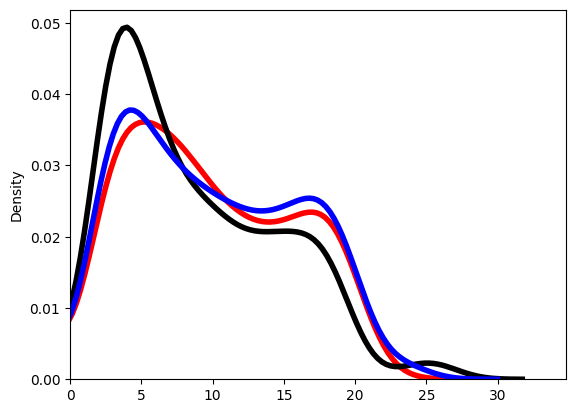

In [164]:
white = long.loc[(long['wall']=='white') & (long['odd']=='right')&(long['start']=='bottom')]
black = long.loc[(long['wall']=='black') & (long['odd']=='right')&(long['start']=='bottom')]
noise = long.loc[(long['wall']=='noise') & (long['odd']=='right')&(long['start']=='bottom')]
sns.distplot(np.concatenate(white.distance_from_edge.to_numpy()), hist=False, kde=True, 
             bins=int(180/5), color = 'red', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(black.distance_from_edge.to_numpy()), hist=False, kde=True, 
             bins=int(180/5), color = 'black', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(noise.distance_from_edge.to_numpy()), hist=False, kde=True, 
             bins=int(180/5), color = 'blue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
plt.xlim(left = 0)

(0.0, 31.89653587589853)

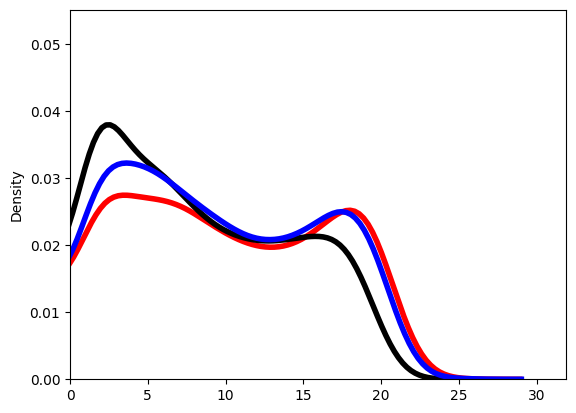

In [163]:
white = long.loc[(long['wall']=='white') & (long['odd']=='right')&(long['start']=='top')]
black = long.loc[(long['wall']=='black') & (long['odd']=='right')&(long['start']=='top')]
noise = long.loc[(long['wall']=='noise') & (long['odd']=='right')&(long['start']=='top')]
sns.distplot(np.concatenate(white.distance_from_edge.to_numpy()), hist=False, kde=True, 
             bins=int(180/5), color = 'red', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(black.distance_from_edge.to_numpy()), hist=False, kde=True, 
             bins=int(180/5), color = 'black', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(noise.distance_from_edge.to_numpy()), hist=False, kde=True, 
             bins=int(180/5), color = 'blue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
plt.xlim(left = 0)

(0.0, 33.55418540446916)

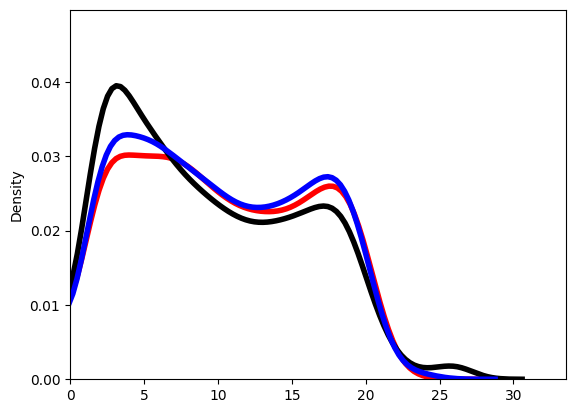

In [161]:
white = long.loc[(long['wall']=='white') ]
black = long.loc[(long['wall']=='black') ]
noise = long.loc[(long['wall']=='noise') ]
sns.distplot(np.concatenate(white.distance_from_edge.to_numpy()), hist=False, kde=True, 
             bins=int(180/5), color = 'red', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(black.distance_from_edge.to_numpy()), hist=False, kde=True, 
             bins=int(180/5), color = 'black', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(noise.distance_from_edge.to_numpy()), hist=False, kde=True, 
             bins=int(180/5), color = 'blue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
plt.xlim(left = 0)

In [ ]:
noise.index.to_numpy()[123   ]

<AxesSubplot: ylabel='Density'>

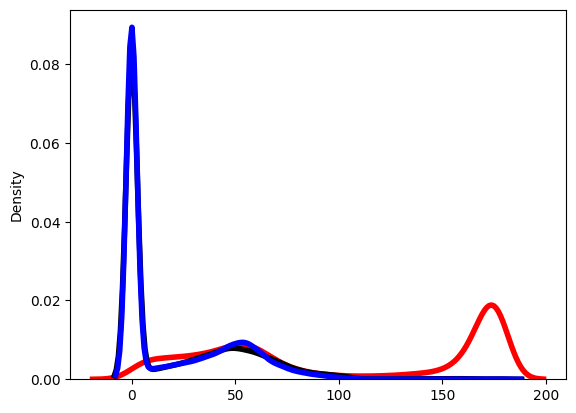

In [159]:
white = long.loc[(long['wall']=='white') ]
black = long.loc[(long['wall']=='black') ]
noise = long.loc[(long['wall']=='noise') ]



noise = noise.drop(index = ([21515,8672]))

sns.distplot(np.concatenate(white.angle_to_corner.to_numpy()), hist=False, kde=True, 
             bins=int(180/5), color = 'red', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(black.zero_out_angle_to_corner.to_numpy()), hist=False, kde=True, 
             bins=int(180/5), color = 'black', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(noise.zero_out_angle_to_corner.to_numpy()), hist=False, kde=True, 
             bins=int(180/5), color = 'blue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})


In [ ]:
df

In [ ]:
middle.distance_from_edge

In [ ]:
test = pd.concat([long,short])

In [ ]:
white = short.loc[(short['wall']=='white') & (short['odd']=='right') ]
black = short.loc[(short['wall']=='black') & (short['odd']=='right') ]
noise = short.loc[(short['wall']=='noise') & (short['odd']=='right') ]
sns.distplot(np.concatenate(white.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'red', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(black.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'black', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(noise.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'blue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
plt.xlim(left = 0)

In [ ]:
white = short.loc[(short['wall']=='white') & (short['odd']=='left') ]
black = short.loc[(short['wall']=='black') & (short['odd']=='left') ]
noise = short.loc[(short['wall']=='noise') & (short['odd']=='left') ]
sns.distplot(np.concatenate(white.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'red', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(black.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'black', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(noise.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'blue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
plt.xlim(left = 0)

In [ ]:
white = long.loc[(long['wall']=='white') & (long['odd']=='left') ]
black = long.loc[(long['wall']=='black') & (long['odd']=='left') ]
noise = long.loc[(long['wall']=='noise') & (long['odd']=='left') ]
sns.distplot(np.concatenate(white.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'red', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(black.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'black', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(noise.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'blue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
plt.xlim(left = 0)

In [ ]:
white = long.loc[(long['wall']=='white') & (long['odd']=='right') ]
black = long.loc[(long['wall']=='black') & (long['odd']=='right') ]
noise = long.loc[(long['wall']=='noise') & (long['odd']=='right') ]
sns.distplot(np.concatenate(white.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'red', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(black.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'black', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(noise.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'blue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
plt.xlim(left = 0)

In [ ]:
white = df.loc[(df['wall']=='white') & (df['odd']=='right') ]
black = df.loc[(df['wall']=='black') & (df['odd']=='right') ]
noise = df.loc[(df['wall']=='noise') & (df['odd']=='right') ]
sns.distplot(np.concatenate(white.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'red', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(black.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'black', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(noise.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'blue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
plt.xlim(left = 0)

In [ ]:
white = test.loc[(test['wall']=='white') ]
black = test.loc[(test['wall']=='black') ]
noise = test.loc[(test['wall']=='noise') ]
sns.distplot(np.concatenate(white.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'red', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(black.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'black', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(noise.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'blue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
plt.xlim(left = 0)

In [ ]:
white = short.loc[(short['wall']=='white') ]
black = short.loc[(short['wall']=='black') ]
noise = short.loc[(short['wall']=='noise') ]
sns.distplot(np.concatenate(white.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'red', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(black.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'black', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(noise.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'blue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
plt.xlim(left = 0)

In [ ]:
white = long.loc[(long['obstalce']=='white') ]
black = long.loc[(long['obstalce']=='black') ]
noise = long.loc[(long['obstalce']=='noise') ]
sns.distplot(np.concatenate(white.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'red', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(black.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'black', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(noise.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'blue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
plt.xlim(left = 0)

In [ ]:
white = short.loc[(short['obstalce']=='white') ]
black = short.loc[(short['obstalce']=='black') ]
noise = short.loc[(short['obstalce']=='noise') ]
sns.distplot(np.concatenate(white.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'red', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(black.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'black', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(noise.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'blue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
plt.xlim(left = 0)

In [ ]:
white = test.loc[(test['obstalce']=='white') ]
black = test.loc[(test['obstalce']=='black') ]
noise = test.loc[(test['obstalce']=='noise') ]
sns.distplot(np.concatenate(white.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'red', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(black.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'black', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(np.concatenate(noise.distance_from_edge.to_numpy()), hist=False, kde=True, 
              color = 'blue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
plt.xlim(left = 0)

In [ ]:
black = long.loc[(long['wall']=='black') ]

In [ ]:
white = long.loc[(long['wall']=='white') ]
black = long.loc[(long['wall']=='black') ]
noise = long.loc[(long['wall']=='noise') ]
plt.hist(np.concatenate(white.distance_from_edge.to_numpy()),color = 'red',alpha = .2)
plt.hist(np.concatenate(black.distance_from_edge.to_numpy()),color = 'black',alpha = .2)
plt.hist(np.concatenate(noise.distance_from_edge.to_numpy()),color = 'blue',alpha = .2)
plt.xlim(left = 0)

In [ ]:
density = long.loc[(long['wall']=='black') ]
plt.hist(np.concatenate(density.distance_from_edge.to_numpy()))

In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['wall']=='noise')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['wall']=='white')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = test.loc[(test['wall']=='black')&(test['odd']=='left')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['condition']=='whitenoise')&(long['odd']=='left')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['obstalce']=='black')&(long['odd']=='left')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['obstalce']=='white')&(long['odd']=='left')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['obstalce']=='white')&(long['odd']=='right')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
np.round(x.astype(float),1)

In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['wall']=='black')&(long['odd']=='left')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
ax.hist2d(x=np.round(x.astype(float),1), y=np.round(y.astype(float),1), bins=(10, 8))
plot_arena(density,ax)


In [ ]:
long.columns.to_numpy()

In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['wall']=='black')&(long['odd']=='left')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
sns.kdeplot(x=x, y=y,ax=ax,bw =.2)
plot_arena(density,ax)

In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['wall']=='black')&(long['odd']=='right')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['wall']=='white')&(long['odd']=='left')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['wall']=='white')&(long['odd']=='right')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['wall']=='noise')&(long['odd']=='left')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['wall']=='noise')&(long['odd']=='right')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = short.loc[(short['wall']=='black')&(short['odd']=='left')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = short.loc[(short['wall']=='black')&(short['odd']=='right')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = short.loc[(short['wall']=='white')&(short['odd']=='left')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = short.loc[(short['wall']=='white')&(short['odd']=='right')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = short.loc[(short['wall']=='noise')&(short['odd']=='left')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = short.loc[(short['wall']=='noise')&(short['odd']=='right')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = test.loc[(test['wall']=='black')&(test['odd']=='left')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = test.loc[(test['wall']=='white')&(test['odd']=='left')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = test.loc[(test['wall']=='noise')&(test['odd']=='left')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = middle.loc[(middle['wall']=='black')&(middle['odd']=='left')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = middle.loc[(middle['wall']=='black')&(middle['odd']=='right')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = middle.loc[(middle['wall']=='white')&(middle['odd']=='left')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = middle.loc[(middle['wall']=='white')&(middle['odd']=='right')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = middle.loc[(middle['wall']=='noise')&(middle['odd']=='left')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = middle.loc[(middle['wall']=='noise')&(middle['odd']=='right')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = test.loc[(test['wall']=='white')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = test.loc[(test['wall']=='noise')]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['wall']=='white') & (long['obstacle_cluster']==1)]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)


In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['wall']=='black') & (long['obstacle_cluster']==1)]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
ax.hist2d(x, y, bins=(10, 10), cmap=plt.cm.jet)

In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['wall']=='black') & (long['obstacle_cluster']==0)]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)




In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['obstalce']=='white') & (long['obstacle_cluster']==1)]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)

In [ ]:
long.obstacle_cluster.unique()

In [ ]:
fig,ax = plt.subplots()
density = long.loc[(long['obstalce']=='black') & (long['obstacle_cluster']==1)]
x,y = np.concatenate(density.ts_nose_x_cm.to_numpy()),np.concatenate(density.ts_nose_y_cm.to_numpy())
plot_arena(density,ax)
sns.kdeplot(x=x, y=y,ax=ax)


In [ ]:
fig = plt.figure(figsize = (12,10))
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax3 = plt.subplot2grid((2, 2), (1, 0))
ax4 = plt.subplot2grid((2, 2), (1, 1))
data = long.loc[(long['condition']=='noisewhite')]
for cluster, cluster_frame in data.groupby(['obstacle_cluster']):
    x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
    if cluster == 0:
        plot_arena(cluster_frame,ax1)
        x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
        sns.kdeplot(x=x, y=y,ax=ax1)
    if cluster == 1:
        plot_arena(cluster_frame,ax2)
        x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
        sns.kdeplot(x=x, y=y,ax=ax2)
    if cluster == 4:
        plot_arena(cluster_frame,ax3)
        x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
        sns.kdeplot(x=x, y=y,ax=ax3)
    if cluster == 5:
        plot_arena(cluster_frame,ax4)
        x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
        sns.kdeplot(x=x, y=y,ax=ax4)

In [ ]:
data = long.loc[(long['wall']=='noise')]
plot_trials_sample(data,100)

In [ ]:
data = long.loc[(long['wall']=='white')]
plot_trials_sample(data,100)

In [ ]:
get_mean_median_trace_by_condition(df,'wall')


In [ ]:
condition_by_start_obstalce_average

In [ ]:
for i in df.wall.unique():
    print(i)
    data = df.loc[(df['wall']==i)]
    condition_by_start_obstalce_average(data,'wall')

In [ ]:
get_mean_median_trace_by_condition(df,'condition')
for i in df.condition.unique():
    print(i)
    data = df.loc[(df['condition']==i)]
    condition_by_start_obstalce_average(data,'condition')

In [ ]:
for i in df.wall.unique():
    print(i)
    data = df.loc[(df['wall']==i)]
    plot_trials_sample(data,50)

In [ ]:
for i in df.condition.unique():
    print(i)
    data = df.loc[(df['condition']==i)]
    plot_trials_sample(data,50)

In [ ]:
data = df.loc[(df['wall']=='black')]
plot_trials_sample(data,100)

In [ ]:
data = df.loc[(df['wall']=='noise')]
plot_trials_sample(data,100)

In [ ]:
data = short.loc[(short['wall']=='black')]
plot_trials_sample(data,300)

In [ ]:
data = short.loc[(short['wall']=='white')]
plot_trials_sample(data,300)

In [ ]:
fig = plt.figure(figsize = (12,10))
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax3 = plt.subplot2grid((2, 2), (1, 0))
ax4 = plt.subplot2grid((2, 2), (1, 1))
data = long.loc[(long['wall']=='white')]
for cluster, cluster_frame in data.groupby(['obstacle_cluster']):
    x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
    if cluster == 0:
        plot_arena(cluster_frame,ax1)
        x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
        sns.kdeplot(x=x, y=y,ax=ax1)
    if cluster == 1:
        plot_arena(cluster_frame,ax2)
        x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
        sns.kdeplot(x=x, y=y,ax=ax2)
    if cluster == 4:
        plot_arena(cluster_frame,ax3)
        x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
        sns.kdeplot(x=x, y=y,ax=ax3)
    if cluster == 5:
        plot_arena(cluster_frame,ax4)
        x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
        sns.kdeplot(x=x, y=y,ax=ax4)

In [ ]:
fig = plt.figure(figsize = (12,10))
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax3 = plt.subplot2grid((2, 2), (1, 0))
ax4 = plt.subplot2grid((2, 2), (1, 1))
data = long.loc[(long['wall']=='noise')]
for cluster, cluster_frame in data.groupby(['obstacle_cluster']):
    x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
    if cluster == 0:
        plot_arena(cluster_frame,ax1)
        x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
        sns.kdeplot(x=x, y=y,ax=ax1)
    if cluster == 1:
        plot_arena(cluster_frame,ax2)
        x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
        sns.kdeplot(x=x, y=y,ax=ax2)
    if cluster == 4:
        plot_arena(cluster_frame,ax3)
        x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
        sns.kdeplot(x=x, y=y,ax=ax3)
    if cluster == 5:
        plot_arena(cluster_frame,ax4)
        x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
        sns.kdeplot(x=x, y=y,ax=ax4)

In [ ]:
fig = plt.figure(figsize = (12,10))
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax3 = plt.subplot2grid((2, 2), (1, 0))
ax4 = plt.subplot2grid((2, 2), (1, 1))
data = long.loc[(long['wall']=='black')]
for cluster, cluster_frame in data.groupby(['obstacle_cluster']):
    x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
    if cluster == 0:
        plot_arena(cluster_frame,ax1)
        x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
        sns.kdeplot(x=x, y=y,ax=ax1)
    if cluster == 1:
        plot_arena(cluster_frame,ax2)
        x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
        sns.kdeplot(x=x, y=y,ax=ax2)
    if cluster == 4:
        plot_arena(cluster_frame,ax3)
        x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
        sns.kdeplot(x=x, y=y,ax=ax3)
    if cluster == 5:
        plot_arena(cluster_frame,ax4)
        x,y = np.concatenate(cluster_frame.ts_nose_x_cm.to_numpy()),np.concatenate(cluster_frame.ts_nose_y_cm.to_numpy())
        sns.kdeplot(x=x, y=y,ax=ax4)




In [ ]:
long_df = create_long_df(nob_df)


fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=1, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])

ax1 = fig.add_subplot(panel_1[0,0])
ax2 = fig.add_subplot(panel_2[0,0])
ax3 = fig.add_subplot(panel_3[0,0])

ax1.set_ylabel('cm')
ax1.set_xlabel('cm')
ax2.set_ylabel('cm')
ax2.set_xlabel('cm')
ax3.set_ylabel('cm')
ax3.set_xlabel('cm')

for ind,row in long_df.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>-3).max()
    ax1.plot(row['distance_from_edge'][:length],row['lateral_error'][:length],c = 'grey',alpha = .5)
ax1.invert_xaxis()
rows = long_df.shape[0]
angle_array = np.empty([rows,50])
angle_array[:] =np.nan 
distance_array = np.empty([rows,50])
distance_array[:] =np.nan 

for i,row in enumerate(long_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>-3).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['lateral_error'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(-3, 17, .4)
    ynew = interpolater(xnew)
    distance_array[i] = xnew
    angle_array[i] = ynew
    ax2.plot(xnew,ynew,c = 'grey',alpha = .5)
ax2.invert_xaxis()
print(distance_array.shape,angle_array.shape)
ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
print(np.nanmedian(angle_array,axis = 0).max())
by_consecutive = long_df.groupby(['consecutive'])
for con,con_df in by_consecutive:
    if con == 1:
        first_df = con_df
    if con ==2:
        sec_df = con_df
rows = first_df.shape[0]
angle_array = np.empty([rows,50])
angle_array[:] =np.nan 
distance_array = np.empty([rows,50])
distance_array[:] =np.nan 
for i,row in enumerate(first_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>-3).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['lateral_error'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(-3, 17, .4)
    ynew = interpolater(xnew)
    distance_array[i] = xnew
    angle_array[i] = ynew
    ax3.plot(xnew,ynew,c = 'red',alpha = .01)
ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'purple',label = 'first')
print(distance_array.shape,angle_array.shape)
rows = sec_df.shape[0]
angle_array_sec = np.empty([rows,50])
angle_array_sec[:] =np.nan 
distance_array_sec = np.empty([rows,50])
distance_array_sec[:] =np.nan 
for i,row in enumerate(sec_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>-3).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['lateral_error'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(-3, 17, .4)
    ynew = interpolater(xnew)
    distance_array_sec[i] = xnew
    angle_array_sec[i] = ynew
    ax3.plot(xnew,ynew,c = 'blue',alpha = .01)
ax3.plot(np.nanmedian(distance_array_sec,axis = 0),np.nanmedian(angle_array_sec,axis = 0),c = 'black',label = 'seconed')
print(distance_array_sec.shape,angle_array_sec.shape)
ax3.invert_xaxis()
ax3.legend()
symmetrize_y_axis(ax1)
symmetrize_y_axis(ax2)
symmetrize_y_axis(ax3)

In [ ]:
long_df = create_long_df(nob_df)

fig = plt.figure(constrained_layout=False, figsize=(20, 8),dpi=90)
spec2 = gridspec.GridSpec(ncols=3, nrows=1, figure=fig)
panel_1 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[0])
panel_2 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[1])
panel_3 = gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=spec2[2])

ax1 = fig.add_subplot(panel_1[0,0])
ax2 = fig.add_subplot(panel_2[0,0])
ax3 = fig.add_subplot(panel_3[0,0])

ax1.set_ylabel('deg')
ax1.set_xlabel('cm')
ax1.set_ylim(top=180,bottom=0)
ax2.set_ylabel('deg')
ax2.set_xlabel('cm')
ax2.set_ylim(top=180,bottom=0)
ax3.set_ylabel('deg')
ax3.set_xlabel('cm')
ax3.set_ylim(top=180,bottom=0)

for ind,row in long_df.iterrows():
    #length = int(row['len_facing_corner'])
    length = np.argwhere(row['distance_from_edge']>1).max()
    ax1.plot(row['distance_from_edge'][:length],row['zero_out_angle_to_corner'][:length],c = 'grey',alpha = .5)
ax1.invert_xaxis()
rows = long_df.shape[0]
angle_array = np.empty([rows,50])
angle_array[:] =np.nan 
distance_array = np.empty([rows,50])
distance_array[:] =np.nan 

for i,row in enumerate(long_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>1).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(0, 20, .4)
    ynew = interpolater(xnew)
    distance_array[i] = xnew
    angle_array[i] = ynew
    ax2.plot(xnew,ynew,c = 'grey',alpha = .5)
ax2.invert_xaxis()
print(distance_array.shape,angle_array.shape)
ax2.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'blue')
by_consecutive = long_df.groupby(['consecutive'])
for con,con_df in by_consecutive:
    if con == 1:
        first_df = con_df
    if con ==2:
        sec_df = con_df
rows = first_df.shape[0]
angle_array = np.empty([rows,50])
angle_array[:] =np.nan 
distance_array = np.empty([rows,50])
distance_array[:] =np.nan 
for i,row in enumerate(first_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>1).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(0, 20, .4)
    ynew = interpolater(xnew)
    distance_array[i] = xnew
    angle_array[i] = ynew
    ax3.plot(xnew,ynew,c = 'red',alpha = .01)
ax3.plot(np.nanmedian(distance_array,axis = 0),np.nanmedian(angle_array,axis = 0),c = 'purple',label = 'first')
print(distance_array.shape,angle_array.shape)
rows = sec_df.shape[0]
angle_array_sec = np.empty([rows,50])
angle_array_sec[:] =np.nan 
distance_array_sec = np.empty([rows,50])
distance_array_sec[:] =np.nan 
for i,row in enumerate(sec_df.iterrows()):
    
    #length = int(row[1]['len_facing_corner'])
    length = np.argwhere(row[1]['distance_from_edge']>1).max()
    interpolater = interp1d(row[1]['distance_from_edge'][:length],row[1]['zero_out_angle_to_corner'][:length],fill_value=np.nan,bounds_error=False)
    xnew =  np.arange(0, 20, .4)
    ynew = interpolater(xnew)
    distance_array_sec[i] = xnew
    angle_array_sec[i] = ynew
    ax3.plot(xnew,ynew,c = 'blue',alpha = .01)
ax3.plot(np.nanmedian(distance_array_sec,axis = 0),np.nanmedian(angle_array_sec,axis = 0),c = 'black',label = 'seconed')
print(distance_array_sec.shape,angle_array_sec.shape)
ax3.invert_xaxis()
ax3.legend()

In [ ]:
row

In [ ]:
df.drop(8672)

long_df = long_df.drop(8672)
long_df = long_df.drop(21515)